<a href="https://colab.research.google.com/github/81smithcj-dotcom/MIS710-Assessment-1-/blob/main/MIS710_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MIS710 Assesment 1 - UrbanStay Nighly Price Predication**
StayWise Analytics (SWA)

Prepared for: Ms. Anisha Kumar, UrbanStay

Objective: Build and evaluate a multiple linear regression model to predict nightly prices for StayWise


**Student name: Christina Smith**

Student ID:S226600657


---

**Notebook Purpose and Workflow**

This notebook documents the complete analytics workflow used to investigate the nightly listing prices on the UbanStay platform and to build a multiple linemodel that predicts 'Nighly_Price'

**Workflow:** Business Problem → Data Quality Assessment → Data Cleaning → EDA →
Feature Selection → Regression Modelling → Model Evaluation & Diagnostics → Business Recommendations


**Machine Learning Framing**

| Decision | Choice | Why |
|---|---|---|
| Learning type | **Supervised** | Every record has an observed outcome (`Nightly_Price`), so the model learns a labelled input→output mapping. |
| Task type | **Regression** | The target is continuous (dollars per night), not a category. |
| Algorithm | **Multiple linear regression (OLS)** | Interpretable coefficients expressed in dollars, which lets UrbanStay explain *why* a price is recommended to hosts — essential for a pricing-guidance product. It also provides a transparent performance baseline. |
| Target | `Nightly_Price` | The variable the business wants to explain and predict. |
Learning Type: Supervised - Every record has an observed outcome (Nightly_Price) so the model learns a labelled input- output.










---

## **1 Prepare - load, inspect and clean the data**

1.   Import libraries
2.   Load and inspect the data
3.   Inspect and handle missing data
4.   Exploratory Data Analysis
5.   Encode categorical variables

## **1.1 Import Libraries**

In [1]:

import pandas as pd #for data manipulation and analysis
import numpy as np #for working with arrays

# Set pandas option to opt-in to future downcasting behavior and suppress FutureWarning
pd.set_option('future.no_silent_downcasting', True)

#import data visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

## **1.2 Load and Inspect Data**

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [4]:
import pandas as pd

# IMPORTANT: Please verify the path to your 'UrbanStay.csv' file in Google Drive.
# If the file is not found, check its location in your Drive and update the path below.
# You can use the file browser on the left (folder icon) to get the correct path by right-clicking on the file.
df_raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/UrbanStay.csv')


# Display the first 5 rows of the new data
display(df_raw.head())

,Listing_ID,Host_Name,Property_Type,Location,Bedrooms,Bathrooms,Accommodates,Review_Score,Number_of_Reviews,Superhost,Host_Experience,Cleaning_Fee,Minimum_Nights,Amenities_Score,Instant_Bookable,Nightly_Price
0,997649,Ava Scott,Studio,Outer Suburb,1,2,2,4.50,68,No,6,52.0,5,6.0,Yes,165.42
1,990090,Isla Martin,Apartment,CBD,2,2,4,4.72,22,No,0,48.0,2,6.0,Yes,382.85
2,995427,Priya Walker,Apartment,CBD,2,2,3,4.50,47,Yes,1,32.0,2,6.0,No,276.28
3,996669,Ava Thomas,Townhouse,Inner Suburb,3,3,6,4.55,68,Yes,4,76.0,2,6.0,No,318.71
4,990808,Sophie Singh,Townhouse,CBD,2,2,4,4.58,85,Yes,15,42.0,1,4.0,Yes,357.58


In [5]:
# load dataset


df_raw= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/UrbanStay.csv')

#Inspect the dataset
print(df_raw)

print('Sample size:', df_raw.shape[0])
print('Number of columns:', df_raw.shape[1])

      Listing_ID     Host_Name Property_Type      Location  Bedrooms  \
0         997649     Ava Scott        Studio  Outer Suburb         1   
1         990090   Isla Martin     Apartment           CBD         2   
2         995427  Priya Walker     Apartment           CBD         2   
3         996669    Ava Thomas     Townhouse  Inner Suburb         3   
4         990808  Sophie Singh     Townhouse           CBD         2   
...          ...           ...           ...           ...       ...   
6547      996483  David Taylor         House  Outer Suburb         4   
6548      996458  Daniel Singh         House  Outer Suburb         3   
6549      995974     Lily King     Apartment  Inner Suburb         1   
6550      995812      Arjun Le         House  Outer Suburb         5   
6551      995731   Oliver King     Apartment  Inner Suburb         2   

      Bathrooms  Accommodates  Review_Score  Number_of_Reviews Superhost  \
0             2             2          4.50                

In [6]:

print(df_raw.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6552 entries, 0 to 6551
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Listing_ID         6552 non-null   int64  
 1   Host_Name          6552 non-null   object 
 2   Property_Type      6552 non-null   object 
 3   Location           6552 non-null   object 
 4   Bedrooms           6552 non-null   int64  
 5   Bathrooms          6552 non-null   int64  
 6   Accommodates       6552 non-null   int64  
 7   Review_Score       6356 non-null   float64
 8   Number_of_Reviews  6552 non-null   int64  
 9   Superhost          6552 non-null   object 
 10  Host_Experience    6552 non-null   int64  
 11  Cleaning_Fee       6408 non-null   float64
 12  Minimum_Nights     6552 non-null   int64  
 13  Amenities_Score    6454 non-null   float64
 14  Instant_Bookable   6552 non-null   object 
 15  Nightly_Price      6552 non-null   float64
dtypes: float64(4), int64(7),

In [7]:
print(f"rows:{df_raw.shape[0]:,} Columns: {df_raw.shape[1]}")

rows:6,552 Columns: 16


In [8]:
# describe statistics for numeric variables
# look for errors in min/max (eg zero bdrms, negative prices)
# look for a skew in the data - large gaps between the mean and the median
df_raw.describe() .T

,count,mean,std,min,25%,50%,75%,max
Listing_ID,6552.0,993994.124695,2306.109824,990003.00,991992.750,993986.500,995990.250,998000.00
Bedrooms,6552.0,2.221764,1.198558,1.00,1.000,2.000,3.000,5.00
Bathrooms,6552.0,1.931319,0.716286,1.00,1.000,2.000,2.000,4.00
Accommodates,6552.0,4.826923,2.538777,1.00,3.000,4.000,7.000,10.00
Review_Score,6356.0,4.444421,0.262024,3.38,4.270,4.450,4.630,5.00
Number_of_Reviews,6552.0,51.124695,37.789277,0.00,24.000,43.000,68.000,317.00
Host_Experience,6552.0,4.191697,3.830503,0.00,1.000,3.000,6.000,15.00
Cleaning_Fee,6408.0,64.003901,18.032491,18.00,50.000,63.000,76.000,129.00
Minimum_Nights,6552.0,2.349969,1.833162,1.00,1.000,2.000,3.000,14.00
Amenities_Score,6454.0,5.726526,1.673594,1.00,5.000,6.000,7.000,10.00


***Interpretation***

*   The dataset contains 6,550 listings (rows) and 16 variables (columns)
*   All numeric values are consitent, there is no stray text inside them
*   Listing_ID and Host_Name are an identifyer with personal information. These do not carry meaning for the model and could be a privacy issue. Decision to exclude from modelling
*   The four object columns Property_type, Location, Superhost, Instant Bookable must be checked for inconsistent labels as they are not a numeric value.






## **1.3 Inspect and Handle Missing Data**

Checking for four dimentions of quality

*   missing values
*   duplicates
*   catergory formatting/consistency
*   validity - ranges and outliers

identify privacy issues with data and action in the model

***Missing Values***

In [9]:
# Reload df_raw to its original state (before any imputation) for missing data assessment
df_raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/UrbanStay.csv')

# Re-create Amenities_Score_Band as it depends on Amenities_Score, which might have missing values now.
# This ensures Amenities_Score_Band correctly reflects missingness if Amenities_Score is NaN.
bins = [0, 3, 5, 10]
labels = ['Low (0-3)', 'Medium (4-5)', 'High (6-10)']
df_raw['Amenities_Score_Band'] = pd.cut(df_raw['Amenities_Score'], bins=bins, labels=labels, right=True, include_lowest=True)

print("df_raw reloaded to show original missing values.")

df_raw reloaded to show original missing values.


In [10]:
#Count missing data
for i in df_raw.iloc[:,0:]:
  miss=df_raw[i].isna().sum()
  print(i,'missing: ', miss)

Listing_ID missing:  0
Host_Name missing:  0
Property_Type missing:  0
Location missing:  0
Bedrooms missing:  0
Bathrooms missing:  0
Accommodates missing:  0
Review_Score missing:  196
Number_of_Reviews missing:  0
Superhost missing:  0
Host_Experience missing:  0
Cleaning_Fee missing:  144
Minimum_Nights missing:  0
Amenities_Score missing:  98
Instant_Bookable missing:  0
Nightly_Price missing:  0
Amenities_Score_Band missing:  98


In [11]:
#See the percentage of Missing Data to inform treatment of missing values - keep as median or remove
print((df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False))

Review_Score            2.991453
Cleaning_Fee            2.197802
Amenities_Score         1.495726
Amenities_Score_Band    1.495726
Listing_ID              0.000000
Bedrooms                0.000000
Host_Name               0.000000
Location                0.000000
Property_Type           0.000000
Number_of_Reviews       0.000000
Accommodates            0.000000
Bathrooms               0.000000
Superhost               0.000000
Minimum_Nights          0.000000
Host_Experience         0.000000
Instant_Bookable        0.000000
Nightly_Price           0.000000
dtype: float64


***Interpretation***
The precentage of missing data for each value is:

Review_Score 3%
Cleaning_Fee 2%
Amenity_Score 1.5%

Need to understand if there's a relationship between missing values - are they random or relate to business context?

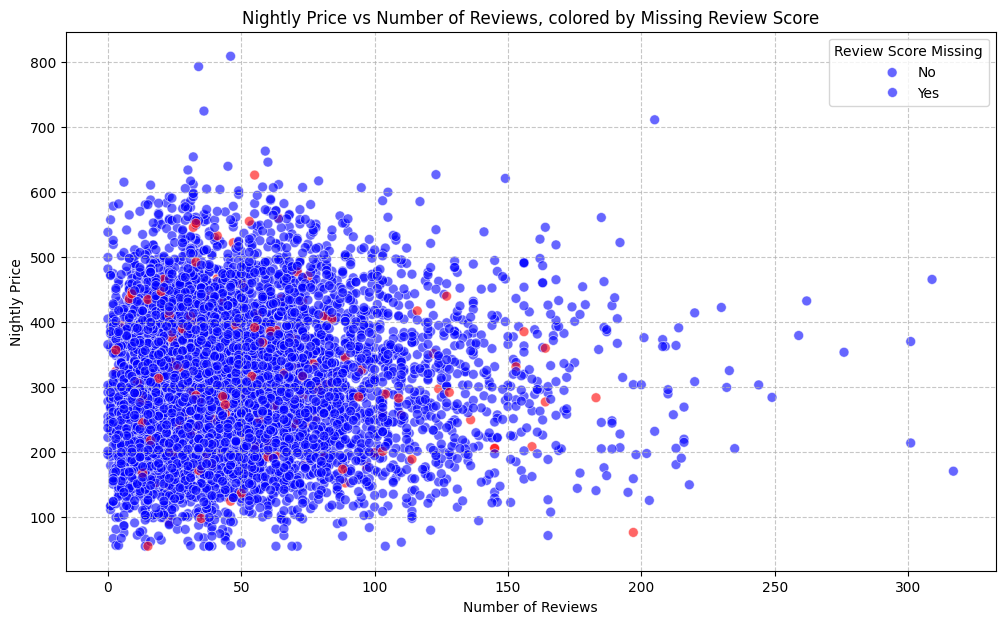

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a boolean column for missing 'Review_Score'
df_raw['is_review_score_missing'] = df_raw['Review_Score'].isnull()

# Create a scatterplot of Nightly_Price vs Number_of_Reviews,
# with hue based on whether Review_Score is missing
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_raw,
    x='Number_of_Reviews',
    y='Nightly_Price',
    hue='is_review_score_missing',
    palette={True: 'red', False: 'blue'},
    alpha=0.6,
    s=50 # size of points
)
plt.title('Nightly Price vs Number of Reviews, colored by Missing Review Score')
plt.xlabel('Number of Reviews')
plt.ylabel('Nightly Price')
plt.legend(title='Review Score Missing', labels=['No', 'Yes'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Drop the temporary column to keep the DataFrame clean
df_raw = df_raw.drop(columns=['is_review_score_missing'])

*Interpretation*

The Review_Score is not presenting as a cluster which means the missing data is random.

Decision: Will chose to impute the missing values with the Review_Score median. Will impute the Cleaning_Fee and Amenities_Score in the same way given they are under 2% and for consistency. Deleting these rows would discrard usable data for listing size, location and price. **do this in step 2.2**

**Duplicate Records**

Check any repeated listing IDs as this is the only uniquie identifier of rows

In [13]:
print(f"Number of duplicate Listing_IDs: {df_raw.Listing_ID.duplicated().sum()}")

Number of duplicate Listing_IDs: 52


In [14]:
# Identify Listing_IDs that appear more than once
# Using keep=False marks all occurrences of a duplicate as True
all_duplicate_rows = df_raw[df_raw['Listing_ID'].duplicated(keep=False)]

# Extract the unique Listing_IDs that are duplicated
dup_ids = all_duplicate_rows['Listing_ID'].unique()

# Now use the first duplicate ID to filter the DataFrame
df_raw[df_raw['Listing_ID'] == dup_ids[0]]

,Listing_ID,Host_Name,Property_Type,Location,Bedrooms,Bathrooms,Accommodates,Review_Score,Number_of_Reviews,Superhost,Host_Experience,Cleaning_Fee,Minimum_Nights,Amenities_Score,Instant_Bookable,Nightly_Price,Amenities_Score_Band
35,990579,Mai White,Apartment,Inner Suburb,2,1,3,4.64,67,No,4,54.0,1,5.0,Yes,233.9,Medium (4-5)
4629,990579,Mai White,Apartment,Inner Suburb,2,1,3,4.64,67,No,4,54.0,1,5.0,Yes,233.9,Medium (4-5)


***Interpretation***

There are  52 duplicated rows for Lising_ID. This inflates the sample size and could overweight the selected listing during model fitting.
Decision: delete duplicate rows


In [15]:
# Remove duplicate rows based on 'Listing_ID', keeping the first occurrence
df_raw.drop_duplicates(subset=['Listing_ID'], inplace=True)

# Verify that duplicates have been removed
print(f"Number of rows after removing duplicates: {df_raw.shape[0]}")
print(f"Number of duplicate Listing_IDs after removal: {df_raw.Listing_ID.duplicated().sum()}")

Number of rows after removing duplicates: 6500
Number of duplicate Listing_IDs after removal: 0


**Categories formatting/consistency**

Inspect the raw category labels so trailing spaces and errors are visable

In [16]:
for col in ['Property_Type', 'Location', 'Superhost', 'Instant_Bookable']:
    print(f"--- {col} ---")
    print(df_raw[col].value_counts(dropna=False))
    print("Raw labels:", [repr(v) for v in df_raw[col].unique()], "\n")

--- Property_Type ---
Property_Type
Apartment     2570
House         1750
Studio        1011
Townhouse      804
Villa          333
apartment       10
Studio           7
Town House       7
HOUSE            7
villa            1
Name: count, dtype: int64
Raw labels: ["'Studio'", "'Apartment'", "'Townhouse'", "'House'", "'Villa'", "'Studio '", "'apartment'", "'villa'", "'Town House'", "'HOUSE'"] 

--- Location ---
Location
Inner Suburb    2067
Outer Suburb    1901
CBD             1382
Regional        1150
Name: count, dtype: int64
Raw labels: ["'Outer Suburb'", "'CBD'", "'Inner Suburb'", "'Regional'"] 

--- Superhost ---
Superhost
No     4105
Yes    2369
N        18
Y         8
Name: count, dtype: int64
Raw labels: ["'No'", "'Yes'", "'N'", "'Y'"] 

--- Instant_Bookable ---
Instant_Bookable
Yes    3867
No     2633
Name: count, dtype: int64
Raw labels: ["'Yes'", "'No'"] 



***Interpretation***

Property_Type and Super_Host have inconsistent formatting. If left uncorrected the model would create seperate values for each category - splitting across two features, weakening the coefficent estimates and making the model harder to interpret.

Decision: remove space, standardise caps replace Y,N with YES, NO

In [17]:
for col in ['Property_Type', 'Superhost']:
    df_raw[col] = df_raw[col].str.strip().str.title()

In [18]:
#check if inconsistencies have been corrected
for col in ['Property_Type', 'Location', 'Superhost', 'Instant_Bookable']:
    print(f"--- {col} ---")
    print(df_raw[col].value_counts(dropna=False))
    print("Raw labels:", [repr(v) for v in df_raw[col].unique()], "\n")

--- Property_Type ---
Property_Type
Apartment     2580
House         1757
Studio        1018
Townhouse      804
Villa          334
Town House       7
Name: count, dtype: int64
Raw labels: ["'Studio'", "'Apartment'", "'Townhouse'", "'House'", "'Villa'", "'Town House'"] 

--- Location ---
Location
Inner Suburb    2067
Outer Suburb    1901
CBD             1382
Regional        1150
Name: count, dtype: int64
Raw labels: ["'Outer Suburb'", "'CBD'", "'Inner Suburb'", "'Regional'"] 

--- Superhost ---
Superhost
No     4105
Yes    2369
N        18
Y         8
Name: count, dtype: int64
Raw labels: ["'No'", "'Yes'", "'N'", "'Y'"] 

--- Instant_Bookable ---
Instant_Bookable
Yes    3867
No     2633
Name: count, dtype: int64
Raw labels: ["'Yes'", "'No'"] 



In [19]:
# Replace 'N' with 'No' and 'Y' with 'Yes' in the 'Superhost' column
df_raw['Superhost'] = df_raw['Superhost'].replace({'N': 'No', 'Y': 'Yes'})

# Verify the changes
print(df_raw['Superhost'].value_counts(dropna=False))

Superhost
No     4123
Yes    2377
Name: count, dtype: int64


In [20]:
# Standardize 'Town House', 'apartment', 'Studio ', 'HOUSE', and 'villa' in the 'Property_Type' column
df_raw['Property_Type'] = df_raw['Property_Type'].replace({
    'Town House': 'Townhouse',
    'apartment': 'Apartment',
    'Studio ': 'Studio',
    'HOUSE': 'House',
    'villa': 'Villa'
})

# Verify the changes
print(df_raw['Property_Type'].value_counts(dropna=False))

Property_Type
Apartment    2580
House        1757
Studio       1018
Townhouse     811
Villa         334
Name: count, dtype: int64


**Data Privacy**

Listing_ID is an arbibitary identifier, Host_Name contains personal information, using it could raise privacy concerns with customers.

Decision: remove non-predictive variables (columns) variables are now 14.

Business consideration: does the business require the use of Listing_ID in the future for other modelling?


In [21]:
df_model = df_raw.drop(columns=['Listing_ID', 'Host_Name'])
print("\nCleaned dataset shape:", df_model.shape)
print("Remaining missing values (handled inside the modelling pipeline):")
print(df_model.isna().sum()[df_model.isna().sum() > 0])


Cleaned dataset shape: (6500, 15)
Remaining missing values (handled inside the modelling pipeline):
Review_Score            195
Cleaning_Fee            143
Amenities_Score          98
Amenities_Score_Band     98
dtype: int64


**Validity - ranges and outliers**

check for outliers in numeric values to see if plausable in business context


In [22]:
checks = {
'Nightly_Price <= 0'        : (df_raw['Nightly_Price'] <= 0).sum(),
    'Bedrooms < 1'              : (df_raw['Bedrooms'] < 1).sum(),
    'Bathrooms < 1'             : (df_raw['Bathrooms'] < 1).sum(),
    'Accommodates < 1'          : (df_raw['Accommodates'] < 1).sum(),
    'Review_Score outside 1-5'  : (~df_raw['Review_Score'].between(1, 5) & df_raw['Review_Score'].notna()).sum(),
    'Number_of_Reviews < 0'     : (df_raw['Number_of_Reviews'] < 0).sum(),
    'Minimum_Nights < 1'        : (df_raw['Minimum_Nights'] < 1).sum(),
}
pd.Series(checks, name='Records_Failing_Check').to_frame()

,Records_Failing_Check
Nightly_Price <= 0,0
Bedrooms < 1,0
Bathrooms < 1,0
Accommodates < 1,0
Review_Score outside 1-5,0
Number_of_Reviews < 0,0
Minimum_Nights < 1,0


Box Plots for Numeric Variables
Check all values fall in business plausiable ranges

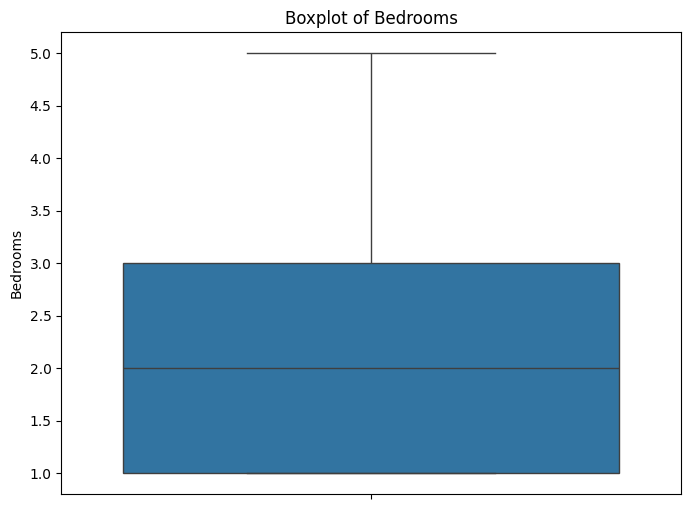

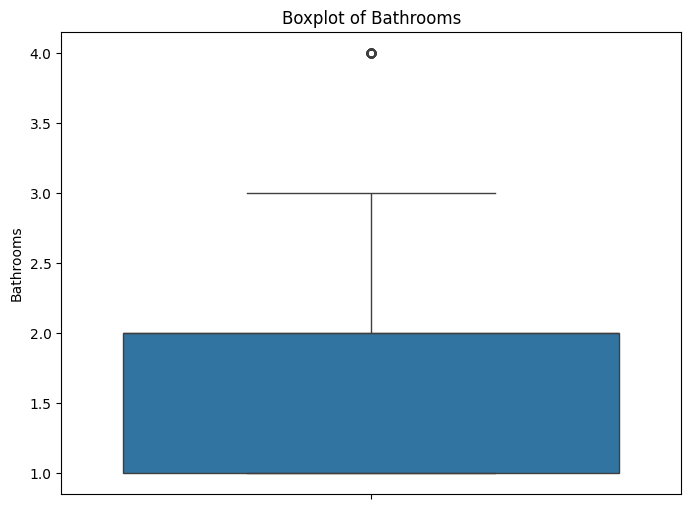

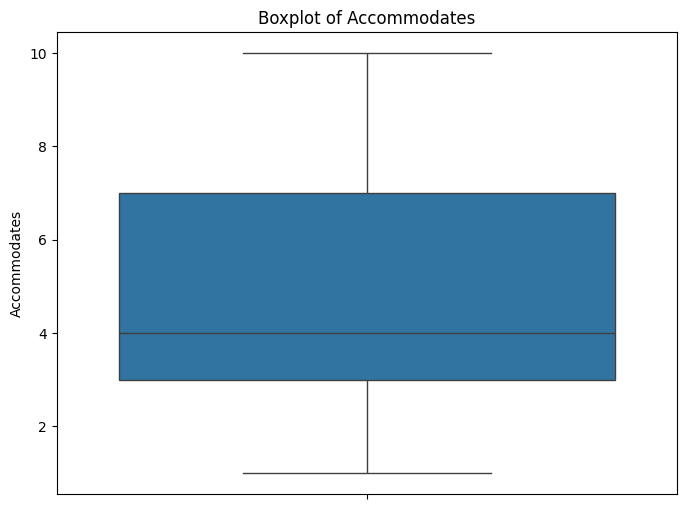

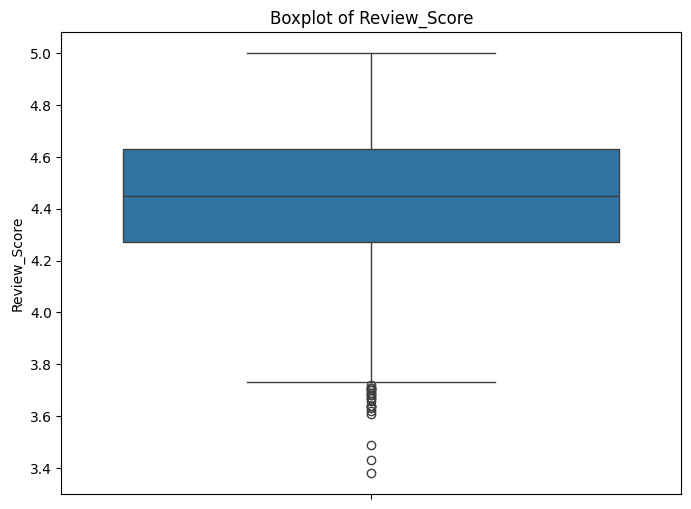

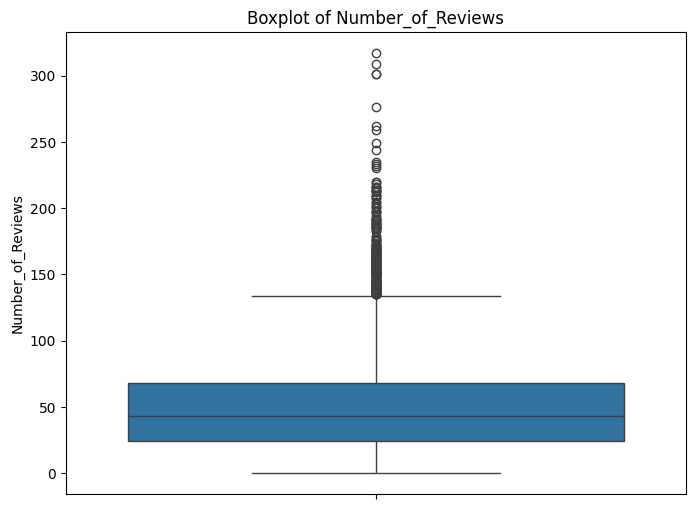

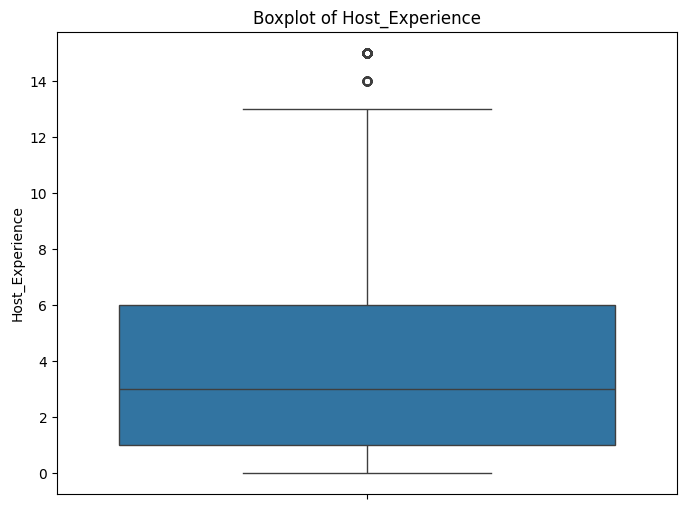

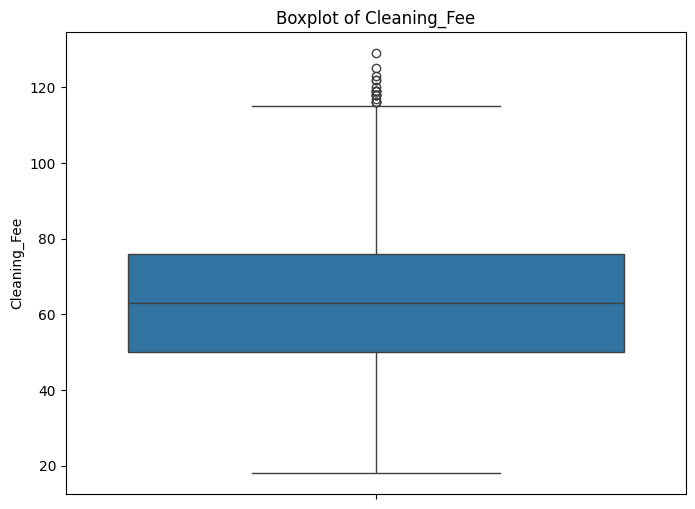

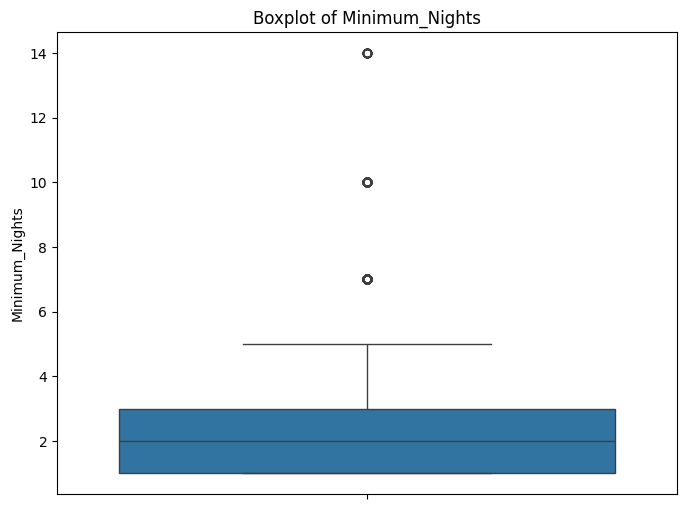

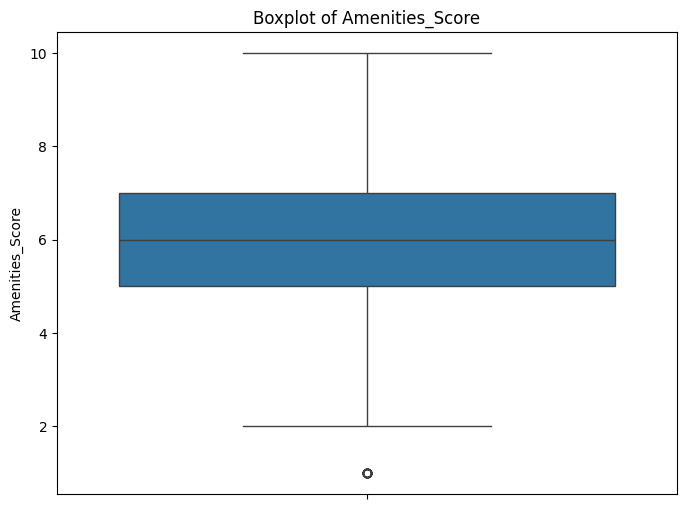

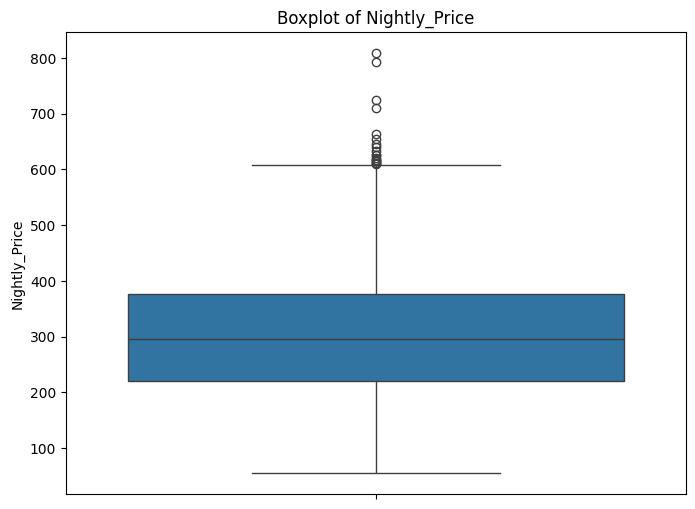

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for box plots
numeric_cols = df_model.select_dtypes(include=['number']).columns

# Create box plots for each numeric column
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df_model[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

*Interpretation*

No invalid values. All prices are positive, room counts are at least one, review scores sit within the 1-5 scale, and minimum nights are at least one.
Nightly_Price has a small number of high-end values (up to ~$800). These are consistent with large villas and houses in the CBD rather than data-entry errors.
Number_of_Reviews and Minimum_Nights are right-skewed, which is normal for this industry — a minority of long-established listings accumulate many reviews.

Decision: retain the outliers. They represent genuine premium listings, and the pricing model must be able to serve those hosts too. Removing them would bias the model toward mid-market properties.

## **1.4 Conduct Exploratory Data Analysis (EDA)**

**Summarise and visualise data**
1.  Univariate analysis - Distribution of target variable 'Nighly_Price'

2.  Bivariate analysis - Relationship between variables and key property, host and listing characteristics in the dataset

3. Treat missing data

3.  Mulitvariate analysis - Relationship Nighly_Price, Host and Review Factors - Identify variables that may not be appropriate for predictive modelling and justify your decisions

*Interpret Patterns throughout*


 **1.4.1 Nightly Price and Key Factors (Univariate analysis)**



summarise the distribution of Nightly_price



In [24]:
# Display descriptive statistics for df_model
display(df_model.describe().T)

,count,mean,std,min,25%,50%,75%,max
Bedrooms,6500.0,2.220000,1.197230,1.00,1.000,2.00,3.0000,5.00
Bathrooms,6500.0,1.930154,0.716058,1.00,1.000,2.00,2.0000,4.00
Accommodates,6500.0,4.824615,2.536578,1.00,3.000,4.00,7.0000,10.00
Review_Score,6305.0,4.444266,0.261799,3.38,4.270,4.45,4.6300,5.00
Number_of_Reviews,6500.0,51.118000,37.795081,0.00,24.000,43.00,68.0000,317.00
Host_Experience,6500.0,4.189538,3.825605,0.00,1.000,3.00,6.0000,15.00
Cleaning_Fee,6357.0,63.973415,18.030734,18.00,50.000,63.00,76.0000,129.00
Minimum_Nights,6500.0,2.351231,1.834813,1.00,1.000,2.00,3.0000,14.00
Amenities_Score,6402.0,5.727117,1.674322,1.00,5.000,6.00,7.0000,10.00
Nightly_Price,6500.0,302.859788,107.598286,55.00,220.935,295.69,376.4425,808.54


In [25]:
#distribution of target variable nightly price
df_raw['Nightly_Price'].describe()

,Nightly_Price
count,6500.000000
mean,302.859788
std,107.598286
min,55.000000
25%,220.935000
50%,295.690000
75%,376.442500
max,808.540000


**Explore numeric variables**

In [26]:
#overview of numeric data- summarise the distribution of variables
df_raw.describe()


,Listing_ID,Bedrooms,Bathrooms,Accommodates,Review_Score,Number_of_Reviews,Host_Experience,Cleaning_Fee,Minimum_Nights,Amenities_Score,Nightly_Price
count,6500.00000,6500.00000,6500.000000,6500.000000,6305.000000,6500.000000,6500.000000,6357.000000,6500.000000,6402.000000,6500.000000
mean,993997.84400,2.22000,1.930154,4.824615,4.444266,51.118000,4.189538,63.973415,2.351231,5.727117,302.859788
std,2305.86994,1.19723,0.716058,2.536578,0.261799,37.795081,3.825605,18.030734,1.834813,1.674322,107.598286
min,990003.00000,1.00000,1.000000,1.000000,3.380000,0.000000,0.000000,18.000000,1.000000,1.000000,55.000000
25%,991996.75000,1.00000,1.000000,3.000000,4.270000,24.000000,1.000000,50.000000,1.000000,5.000000,220.935000
50%,993990.50000,2.00000,2.000000,4.000000,4.450000,43.000000,3.000000,63.000000,2.000000,6.000000,295.690000
75%,995992.25000,3.00000,2.000000,7.000000,4.630000,68.000000,6.000000,76.000000,3.000000,7.000000,376.442500
max,998000.00000,5.00000,4.000000,10.000000,5.000000,317.000000,15.000000,129.000000,14.000000,10.000000,808.540000


In [27]:
#set the formatting for floating numbers
pd.set_option('display.float_format', lambda x: '%.3f' % x)

data_types =['object', 'float', 'int']
df_raw.describe(include=data_types)

,Listing_ID,Host_Name,Property_Type,Location,Bedrooms,Bathrooms,Accommodates,Review_Score,Number_of_Reviews,Superhost,Host_Experience,Cleaning_Fee,Minimum_Nights,Amenities_Score,Instant_Bookable,Nightly_Price
count,6500.000,6500,6500,6500,6500.000,6500.000,6500.000,6305.000,6500.000,6500,6500.000,6357.000,6500.000,6402.000,6500,6500.000
unique,NaN,998,5,4,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,2,NaN
top,NaN,Emily Anderson,Apartment,Inner Suburb,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,Yes,NaN
freq,NaN,18,2580,2067,NaN,NaN,NaN,NaN,NaN,4123,NaN,NaN,NaN,NaN,3867,NaN
mean,993997.844,NaN,NaN,NaN,2.220,1.930,4.825,4.444,51.118,NaN,4.190,63.973,2.351,5.727,NaN,302.860
std,2305.870,NaN,NaN,NaN,1.197,0.716,2.537,0.262,37.795,NaN,3.826,18.031,1.835,1.674,NaN,107.598
min,990003.000,NaN,NaN,NaN,1.000,1.000,1.000,3.380,0.000,NaN,0.000,18.000,1.000,1.000,NaN,55.000
25%,991996.750,NaN,NaN,NaN,1.000,1.000,3.000,4.270,24.000,NaN,1.000,50.000,1.000,5.000,NaN,220.935
50%,993990.500,NaN,NaN,NaN,2.000,2.000,4.000,4.450,43.000,NaN,3.000,63.000,2.000,6.000,NaN,295.690
75%,995992.250,NaN,NaN,NaN,3.000,2.000,7.000,4.630,68.000,NaN,6.000,76.000,3.000,7.000,NaN,376.442


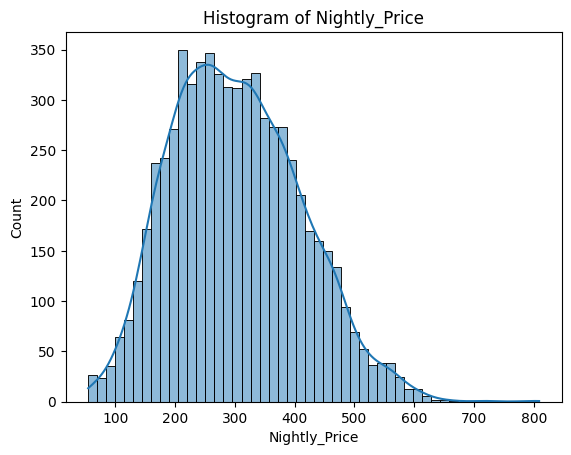

In [28]:
#visualise its distribution
sns.histplot(data=df_raw, x='Nightly_Price', kde=True, bins=50)
plt.title(f"Histogram of Nightly_Price")
plt.show()

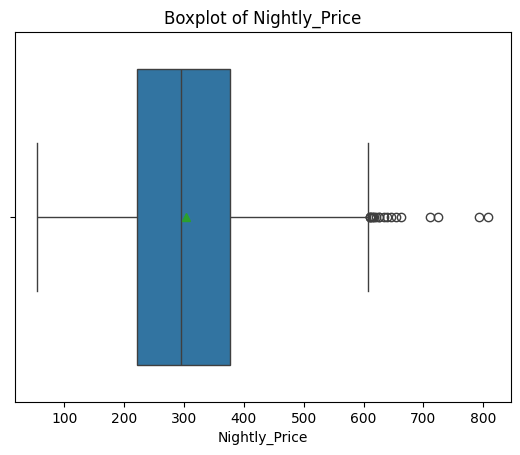

In [29]:
sns.boxplot(data=df_raw, x='Nightly_Price', showmeans=True)
plt.title(f"Boxplot of Nightly_Price")
plt.show()

*Interpretation* Nightly_Price Mean is $302. Right skew towards premium listings.

**1.4.2  Bivariate analysis - Relationship between variables and key property, host and listing characteristics in the dataset and 'Nighly_Price'**

**Nightly Price by Property, Host and Review Factors**

Investigate how Nightly_Price varies across selected business factors.

Amenities_Score_Band
High (6-10)     3562
Medium (4-5)    2261
Low (0-3)        579
Name: count, dtype: int64


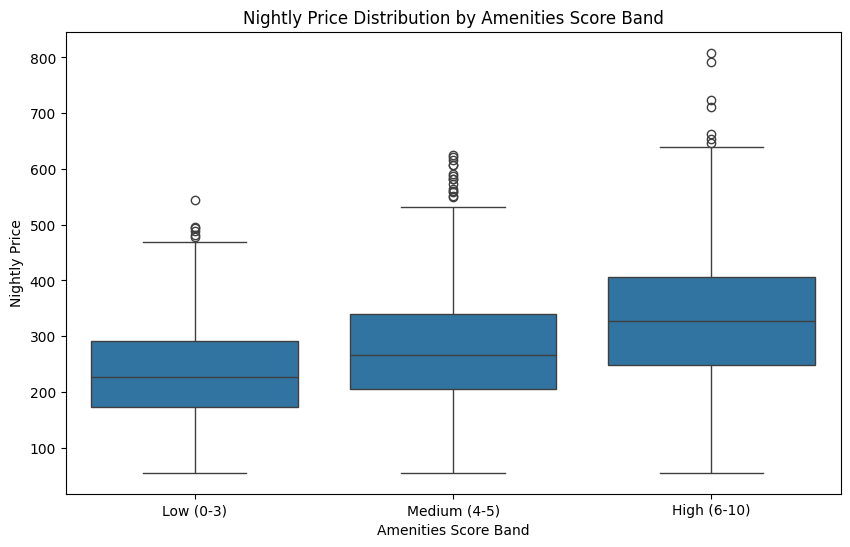

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the bins and labels as requested
bins = [0, 3, 5, 10]
labels = ['Low (0-3)', 'Medium (4-5)', 'High (6-10)']

# Create a new categorical column for Amenities_Score bands
df_raw['Amenities_Score_Band'] = pd.cut(df_raw['Amenities_Score'], bins=bins, labels=labels, right=True, include_lowest=True)

# Display the value counts for the new column to verify
print(df_raw['Amenities_Score_Band'].value_counts())

# Create a box plot to show the relationship between Amenities_Score_Band and Nightly_Price
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_raw, x='Amenities_Score_Band', y='Nightly_Price', order=labels)
plt.title('Nightly Price Distribution by Amenities Score Band')
plt.xlabel('Amenities Score Band')
plt.ylabel('Nightly Price')
plt.show()


In [31]:
# Code below to summarise the apartment listing frequency for 'Regional' location
df_raw[df_raw['Location'] == 'Regional']['Property_Type'].value_counts()

,count
Property_Type,
Apartment,431
House,329
Studio,198
Townhouse,138
Villa,54


In [32]:
# Code below to summarise the apartment listing frequency for 'CBD' location
df_raw[df_raw['Location'] == 'CBD']['Property_Type'].value_counts()

,count
Property_Type,
Apartment,548
House,366
Studio,210
Townhouse,179
Villa,79


*Interpretation*

Average nightly price is higher in CBD then inner suburbs

Outer Suburbs and Regional hold simlar values



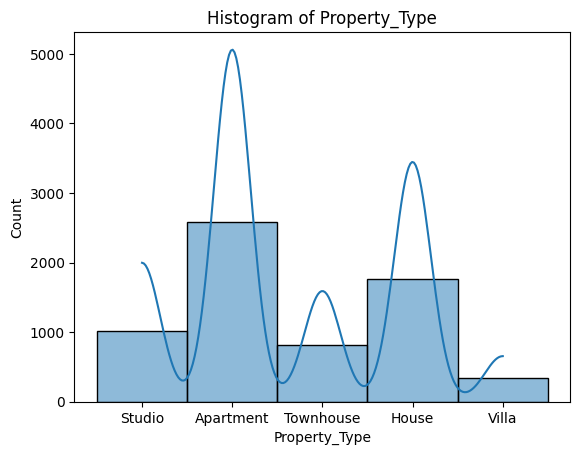

In [33]:
## code below to generate a histogram of price
sns.histplot(data=df_raw, x='Property_Type', kde=True, bins=50)
plt.title(f"Histogram of Property_Type")
plt.show()

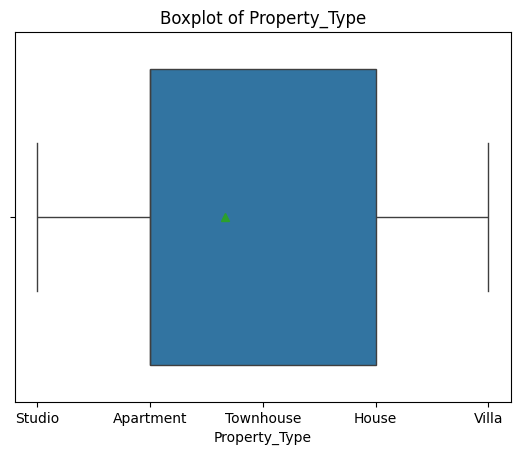

In [34]:
##write your code below to generate a boxplot of price
sns.boxplot(data=df_raw, x='Property_Type', showmeans=True)
plt.title(f"Boxplot of Property_Type")
plt.show()

**Visualise multiple numerical variables using a loop**

Numerical Variables: ['Listing_ID', 'Bedrooms', 'Bathrooms', 'Accommodates', 'Review_Score', 'Number_of_Reviews', 'Host_Experience', 'Cleaning_Fee', 'Minimum_Nights', 'Amenities_Score', 'Nightly_Price']


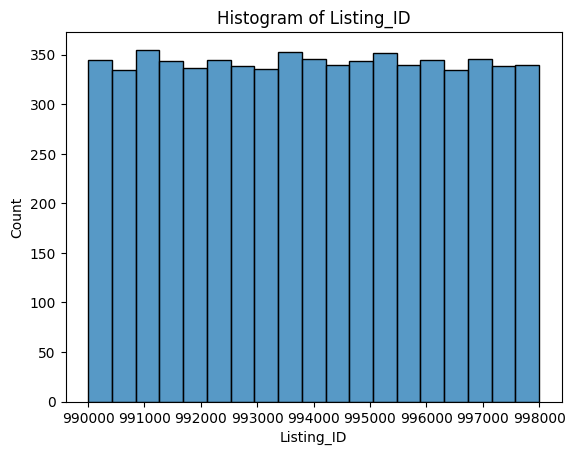

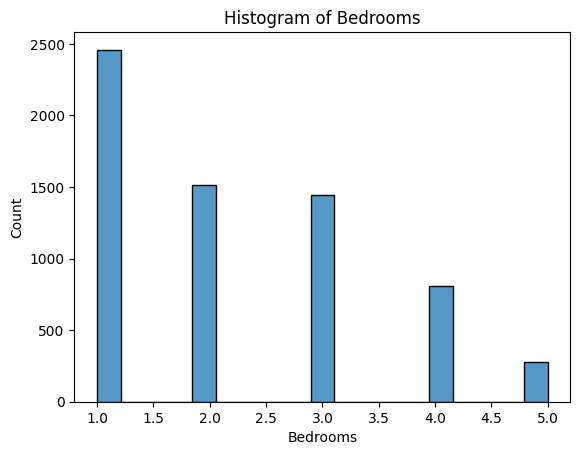

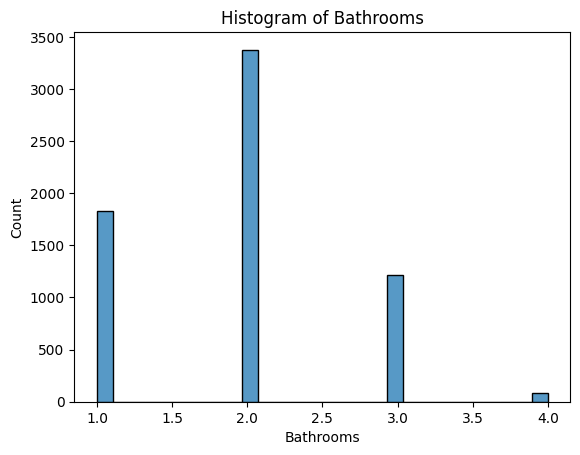

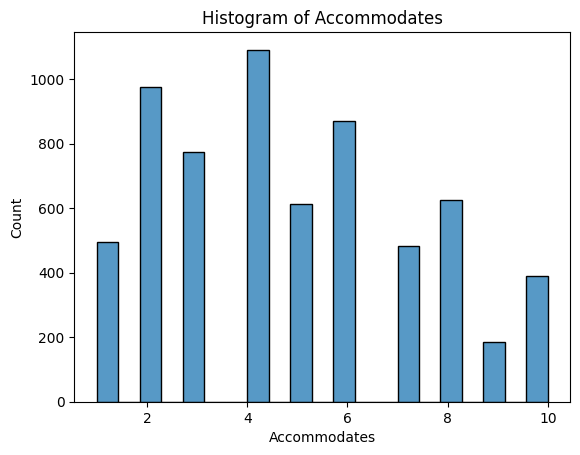

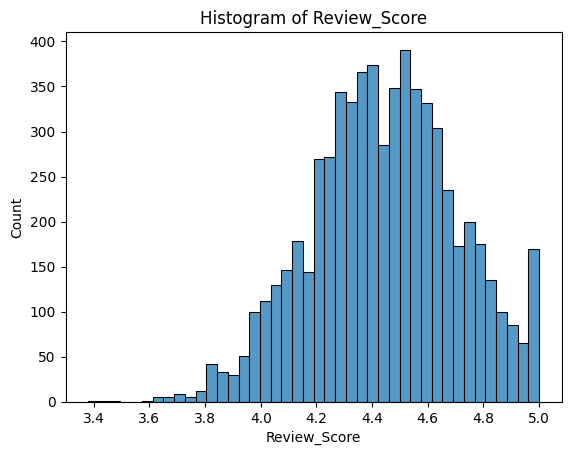

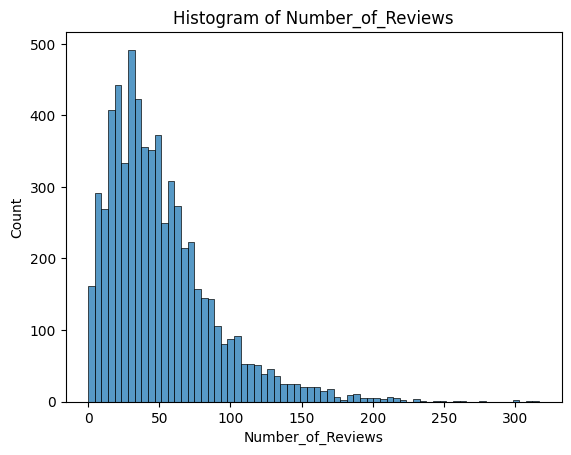

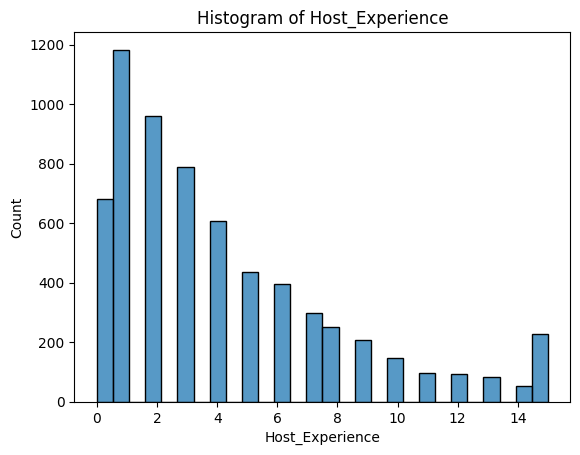

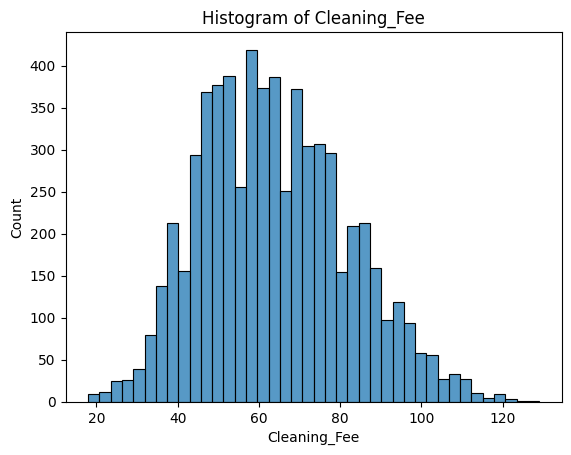

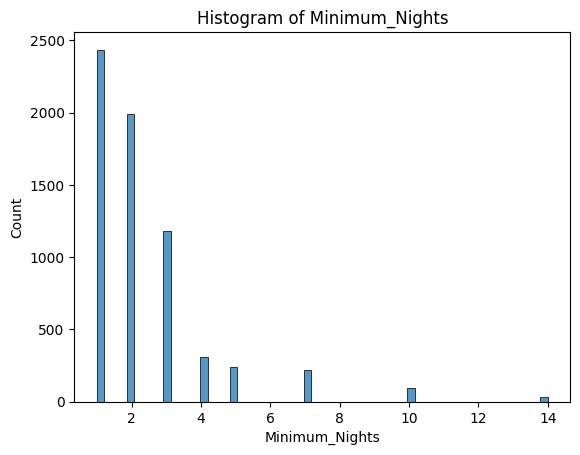

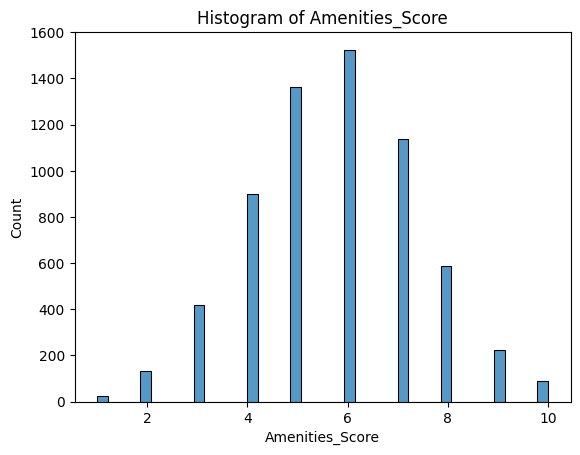

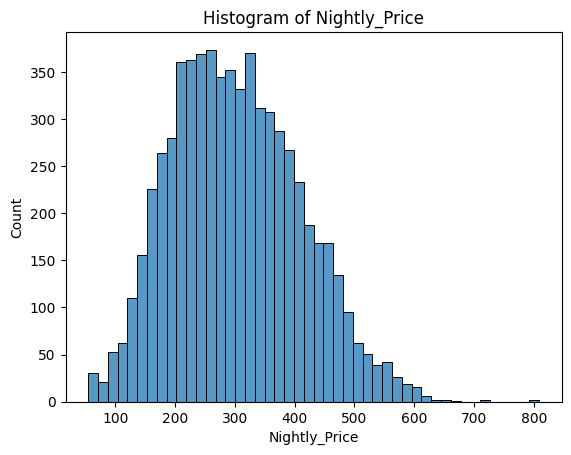

In [35]:
#using seaborn https://seaborn.pydata.org/generated/seaborn.histplot.html
# Get the numerical variables from the dataset
numerical_variables = df_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Print the list of numerical variables
print("Numerical Variables:", numerical_variables)

# Display histograms using seaborn
for variable in numerical_variables:
    sns.histplot(data=df_raw, x=variable)
    plt.title(f"Histogram of {variable}")
    plt.show()



**Explore categorical variables**

*Interpretation*: No relationship between Host and Nightly_Price as Hosts can manage more than one property with different variables. Example Host 'Chole White" Manages properites from 1-5 bedrooms. Host Name is not a determinig factor in Nighly_Price. Further data privacy for Hosts is a consideration.

Decision: remove Host_Name from model

In [36]:
#explore each categorial variable
print(df_raw['Nightly_Price'].value_counts())


Nightly_Price
55.000     10
232.790     4
161.870     3
175.740     3
288.080     3
           ..
293.370     1
102.470     1
368.240     1
159.590     1
296.240     1
Name: count, Length: 5948, dtype: int64


In [37]:
#find mode
print('Nightly_Price: ', df_raw['Nightly_Price'].mode())

Nightly_Price:  0   55.000
Name: Nightly_Price, dtype: float64


<Axes: xlabel='Location', ylabel='count'>

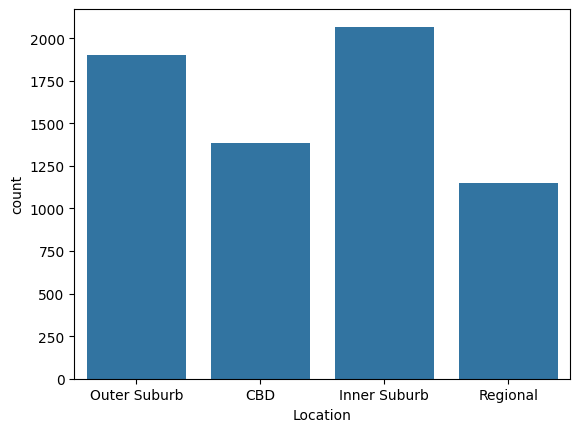

In [38]:
#summarise a categorical variable using a barchart (countplot)
sns.countplot(data=df_raw, x='Location')

In [39]:
# Calculate median Nightly_Price for 'Regional' location
regional_median_price = df_raw[df_raw['Location'] == 'Regional']['Nightly_Price'].median()
print(f"Median Nightly_Price in Regional areas: {regional_median_price:.2f}")

# Calculate median Nightly_Price for 'CBD' location
cbd_median_price = df_raw[df_raw['Location'] == 'CBD']['Nightly_Price'].median()
print(f"Median Nightly_Price in CBD areas: {cbd_median_price:.2f}")

Median Nightly_Price in Regional areas: 256.56
Median Nightly_Price in CBD areas: 340.29


In [40]:
avg_price_by_location = df_raw.groupby('Location')['Nightly_Price'].mean().reset_index()
display(avg_price_by_location)

,Location,Nightly_Price
0,CBD,350.072
1,Inner Suburb,310.578
2,Outer Suburb,283.970
3,Regional,263.476


Mean for both CBD and regional nightly_price is slightly higher than the median ($10 per night) which indicates a few unusually high values. this is due to a few high-end properties (outliers) slighly skewing the data to the right.

In [41]:
#write code to print frequency of Superhost
df_raw['Superhost'].value_counts()

,count
Superhost,
No,4123
Yes,2377


<Axes: xlabel='Superhost', ylabel='count'>

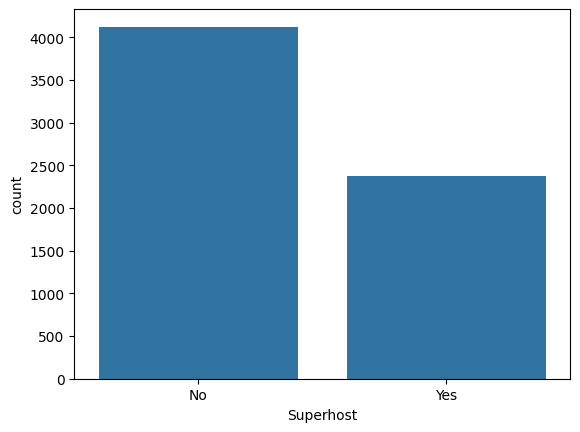

In [42]:

##write your code to generate a countplot for another categorical variable, such as superhost
sns.countplot(data=df_raw, x='Superhost')

In [43]:
#write your code to explore another variables
print(df_raw['Bathrooms'].value_counts())

Bathrooms
2    3376
1    1829
3    1215
4      80
Name: count, dtype: int64


In [44]:
#find mode
print('Most frequent number of bathrooms: ', df_raw['Bathrooms'].mode())

Most frequent number of bathrooms:  0    2
Name: Bathrooms, dtype: int64


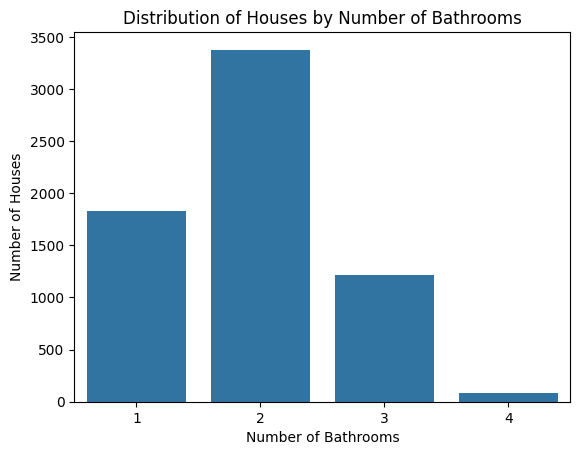

In [45]:
#write your code to visualise the barchart (countplot) of bathrooms
sns.countplot(x=df_raw['Bathrooms'])
plt.xlabel('Number of Bathrooms')
plt.ylabel('Number of Houses')
plt.title('Distribution of Houses by Number of Bathrooms')
plt.show()

### **1.4.3 Treat missing data**

Missing data dealt with in data cleansing

In [46]:
# Impute missing values in 'Amenities_Score' with its median
df_raw['Amenities_Score'] = df_raw['Amenities_Score'].fillna(df_raw['Amenities_Score'].median())

print("Missing values in 'Amenities_Score' after imputation:")
print(df_raw['Amenities_Score'].isnull().sum())

Missing values in 'Amenities_Score' after imputation:
0


In [47]:
# Impute missing values in 'Cleaning_Fee' with its median
df_raw['Cleaning_Fee'] = df_raw['Cleaning_Fee'].fillna(df_raw['Cleaning_Fee'].median())

print("Missing values in 'Cleaning_Fee' after imputation:")
print(df_raw['Cleaning_Fee'].isnull().sum())

Missing values in 'Cleaning_Fee' after imputation:
0


In [48]:
# Impute missing values in 'Review_Score' with its median
df_raw['Review_Score'] = df_raw['Review_Score'].fillna(df_raw['Review_Score'].median())

print("Missing values in 'Review_Score' after imputation:")
print(df_raw['Review_Score'].isnull().sum())

Missing values in 'Review_Score' after imputation:
0


Now, rerun the analyses above with the cleansed dataset

**Reporting**


*   What are the central tendency, key data points, variability, and distribution shape of each numerical variable?
*   What are the frequency and mode in the distribution of each categorical variable?
*   How do you interpret the distributions?
*   Did you identify and address outliers? How and Why?
*   What business insights and implications can you derive from this analysis?


### **1.4.4 Bivariate and Multivariate Analysis & Business insights**



**Display a countplot for one categorical variable grouped by a second categorical variable**
https://seaborn.pydata.org/generated/seaborn.countplot.html

<Axes: xlabel='Review_Score', ylabel='Nightly_Price'>

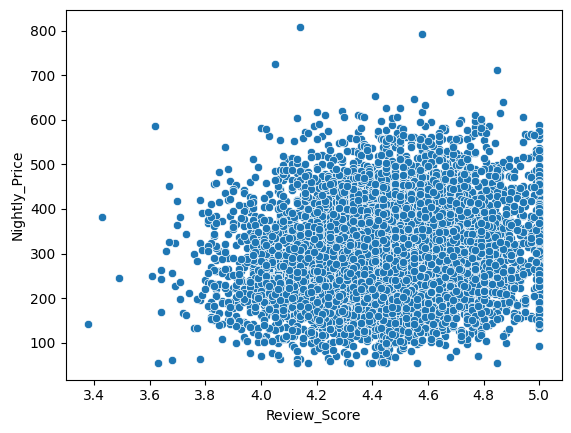

In [49]:
# Display contingency table between Review_Score and nightly price from the 'df_raw' dataset
import pandas as pd
import seaborn as sns

sns.scatterplot(x=df_raw['Review_Score'], y=df_raw['Nightly_Price'])

*Interpretation*

Limited correlation between nighly price and review score, test this in modelling later

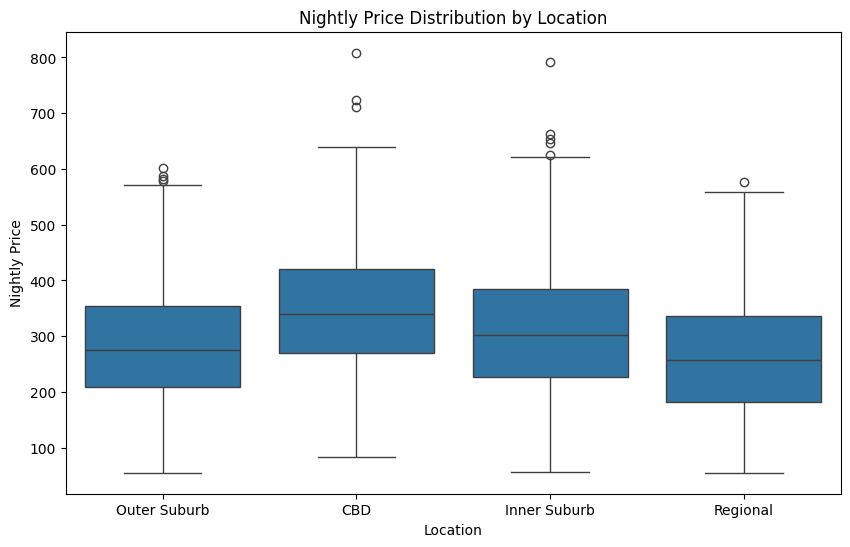

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_raw, x='Location', y='Nightly_Price')
plt.title('Nightly Price Distribution by Location')
plt.xlabel('Location')
plt.ylabel('Nightly Price')
plt.show()

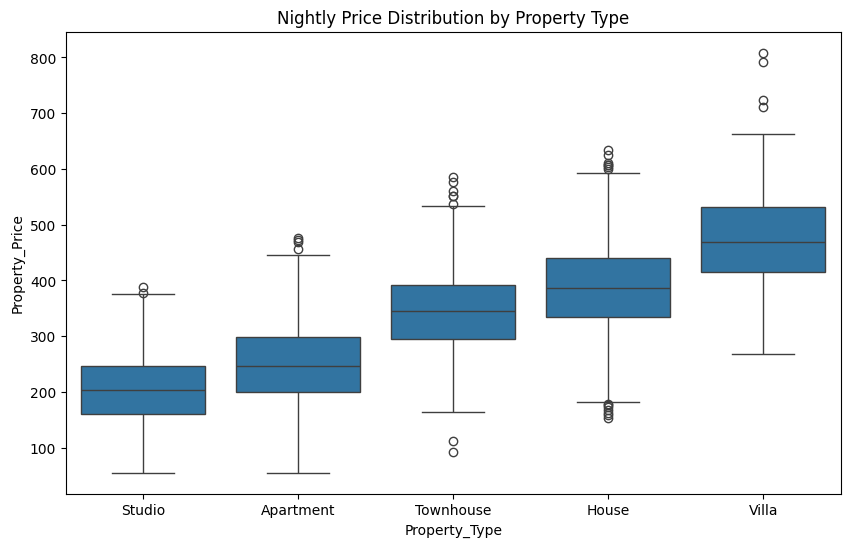

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_raw, x='Property_Type', y='Nightly_Price')
plt.title('Nightly Price Distribution by Property Type')
plt.xlabel('Property_Type')
plt.ylabel('Property_Price')
plt.show()

*Interpretation*

Property Pricing is heavily correlated to Propety Type. Villa properties commanding the highest nighly rate followed by Houses although some houses have outliers of lower rates under $200 per night.

In [52]:
# Calculate the median Nightly_Price
median_nightly_price = df_raw['Nightly_Price'].median()

# Sort the DataFrame by Nightly_Price
df_sorted = df_raw.sort_values(by='Nightly_Price').reset_index(drop=True)

# Find the index of the first row with Nightly_Price >= median_nightly_price
median_idx = df_sorted[df_sorted['Nightly_Price'] >= median_nightly_price].index[0]

# Select 20 rows around the median index (10 before, 10 after)
start_idx = max(0, median_idx - 10)
end_idx = min(len(df_sorted), median_idx + 10)

df_sample = df_sorted.iloc[start_idx:end_idx]

# Display the contingency table for the sampled data
contingency_table = pd.crosstab(df_sample['Nightly_Price'], df_sample['Superhost'])
display(contingency_table)

Superhost,No,Yes
Nightly_Price,,
295.330,0,1
295.340,1,0
295.350,1,0
295.440,0,1
295.480,0,1
295.580,3,0
295.600,1,0
295.680,1,0
295.700,1,0


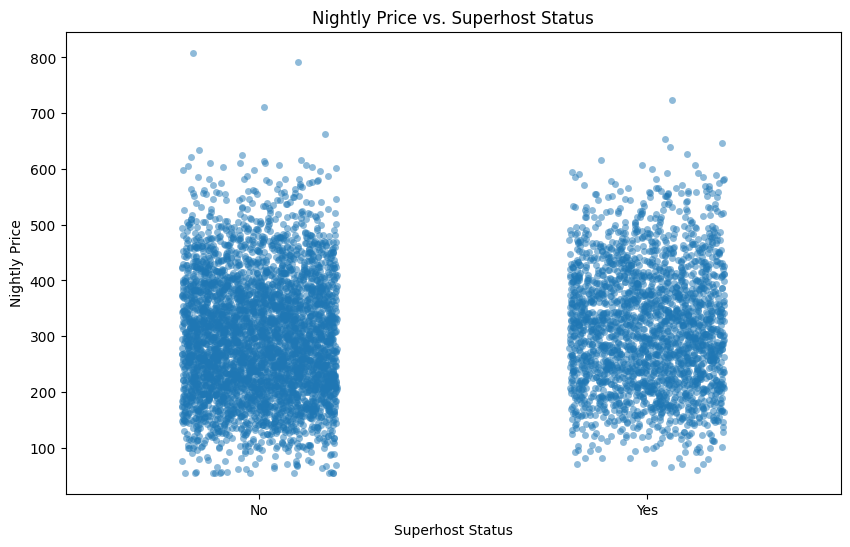

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.stripplot(data=df_raw, x='Superhost', y='Nightly_Price', jitter=0.2, alpha=0.5)
plt.title('Nightly Price vs. Superhost Status')
plt.xlabel('Superhost Status')
plt.ylabel('Nightly Price')
plt.show()

*Interpretation*

There is no clear relationship between nightly_price and Superhost Status.

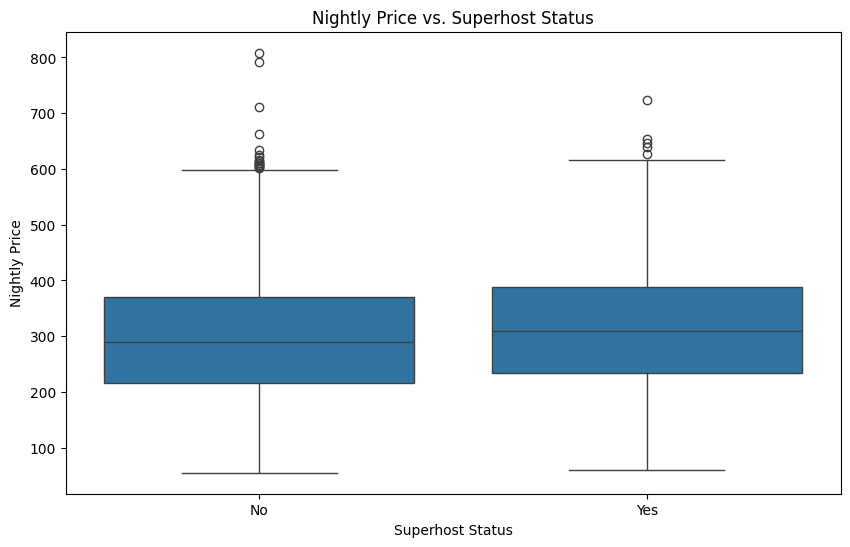

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_raw, x='Superhost', y='Nightly_Price')
plt.title('Nightly Price vs. Superhost Status')
plt.xlabel('Superhost Status')
plt.ylabel('Nightly Price')
plt.show()

*Interpretation*

Superhost status shows only a modest pricing difference. Should not attribute the badge of "Superhost" with a premium price tier

<Axes: xlabel='Bathrooms', ylabel='count'>

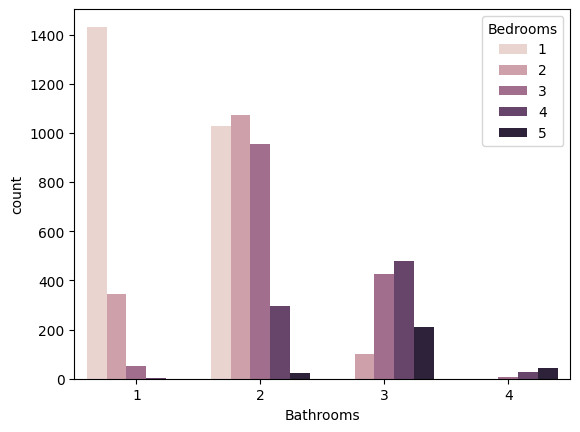

In [55]:
##examine relationships between other categorical variables
sns.countplot(data= df_raw, x='Bathrooms', hue='Bedrooms')

<Axes: xlabel='Bedrooms', ylabel='Nightly_Price'>

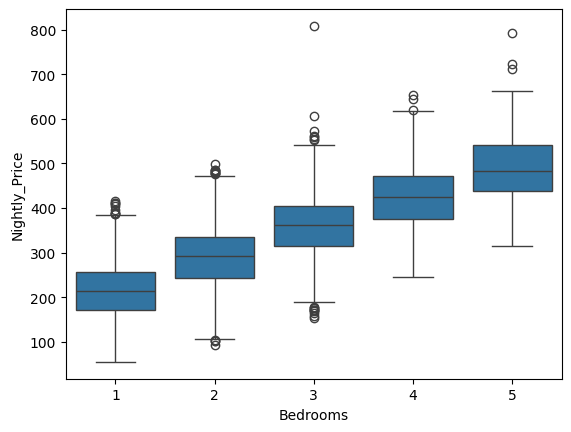

In [56]:
sns.boxplot(data=df_raw, x='Bedrooms', y='Nightly_Price')

<Axes: xlabel='Location', ylabel='Nightly_Price'>

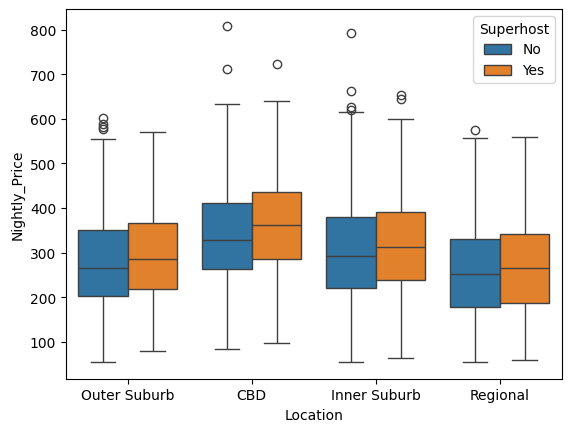

In [57]:
##examine boxplots of price by Location and Nighlyprice and Superhost
sns.boxplot(data=df_raw, x='Location', y='Nightly_Price', hue='Superhost')

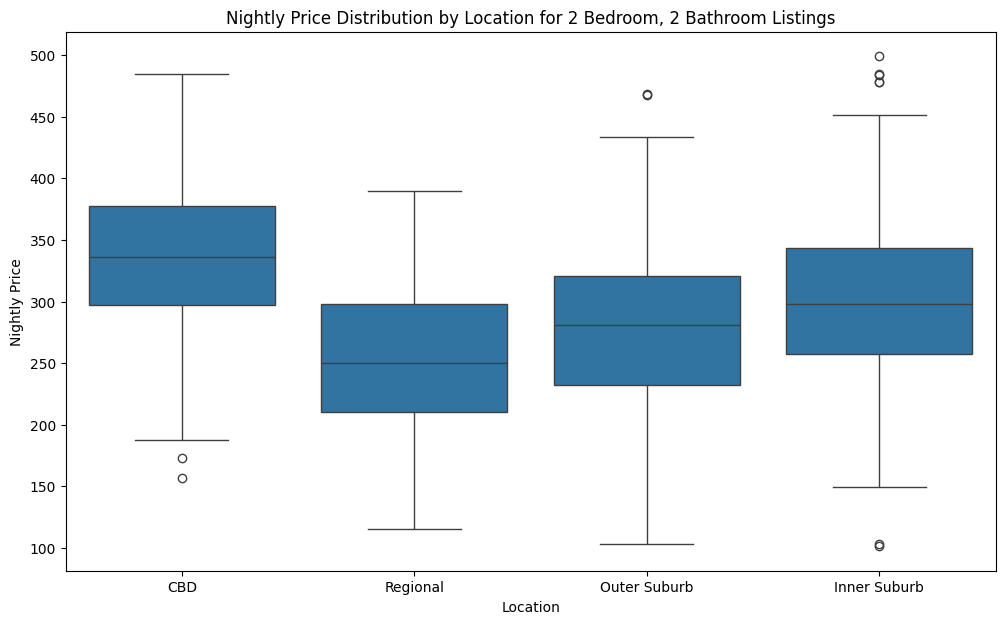

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame for listings with 2 bedrooms and 2 bathrooms
df_filtered = df_raw[(df_raw['Bedrooms'] == 2) & (df_raw['Bathrooms'] == 2)]

# Create the box plot
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_filtered, x='Location', y='Nightly_Price')
plt.title('Nightly Price Distribution by Location for 2 Bedroom, 2 Bathroom Listings')
plt.xlabel('Location')
plt.ylabel('Nightly Price')
plt.show()

*Inerpretation*

Nightly_price is driven by location. CBD commanding the highest premium followed by inner and outer suburbs.the gap for compariable properties in CBD Vs Regional is $100 per night

<Axes: xlabel='Bedrooms', ylabel='Nightly_Price'>

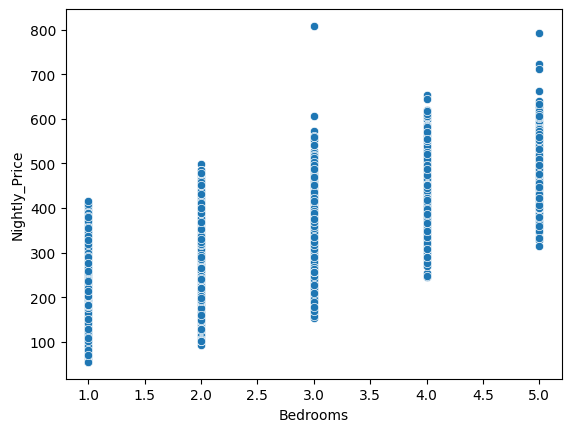

In [59]:
sns.scatterplot(data=df_raw, x='Bedrooms', y='Nightly_Price')

In [60]:
#define my own array of numeric variables of interest
numerical_variables  = ['Nightly_Price', 'Bedrooms', 'Bathrooms', 'Accommodates', 'Review_Score', 'Number_of_Reviews', 'Host_Experience', 'Cleaning_Fee', 'Minimum_Nights', 'Amenities_Score']

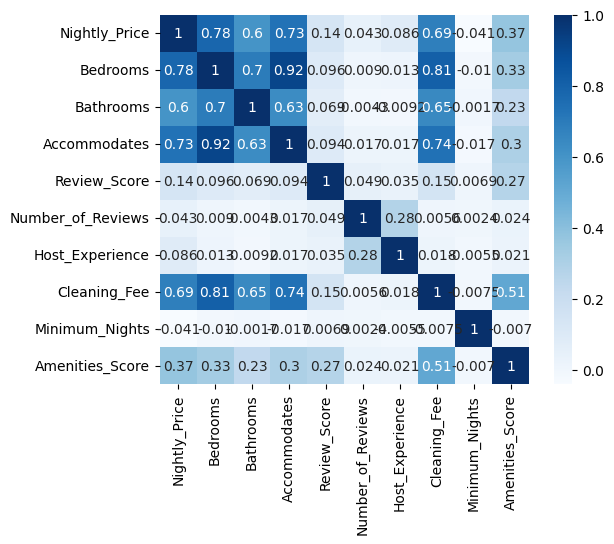

In [61]:
#generate heatmaps to explore relationships
sns.heatmap(df_raw[numerical_variables].corr(), square=True, cmap='Blues', annot=True)
plt.show()

In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


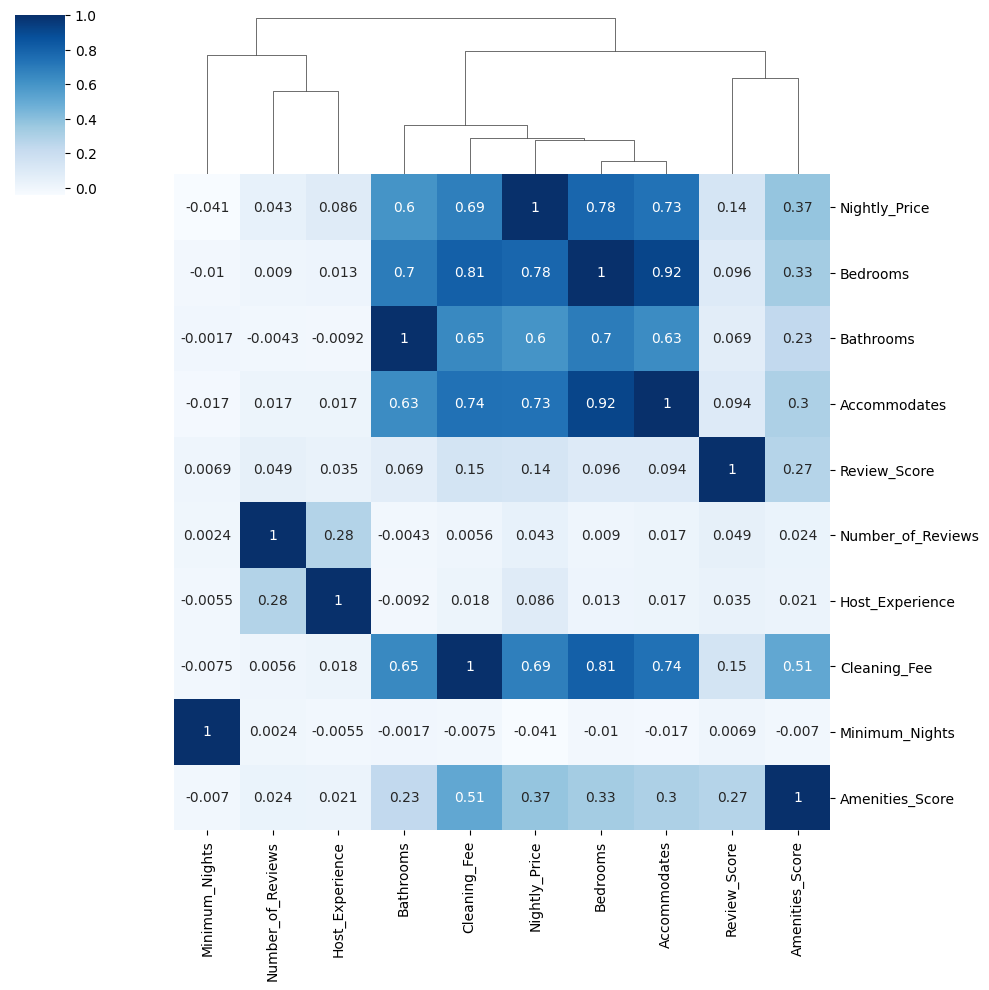

In [63]:
#generate clustermap to show hierarchical clustering
sns.clustermap(df_raw[numerical_variables].corr(), cmap='Blues', annot=True, row_cluster=False)
plt.show()

*Interpretation*

| Variable | r with price | Business reading |
|---|---|---|
| `Bedrooms` | ≈ 0.78 | **Strongest single driver.** Capacity to sleep more guests commands the largest premium. |
| `Accommodates` | ≈ 0.73 | Confirms the capacity story — closely tied to bedrooms. |
| `Cleaning_Fee` | ≈ 0.69 | Larger properties cost more to service, so the fee scales with property size. |
| `Bathrooms` | ≈ 0.60 | A secondary size/comfort dimension. |
| `Amenities_Score` | ≈ 0.38 | A moderate, actionable lever — better-equipped listings charge more. |
| `Review_Score` | ≈ 0.14 | Weak. Quality ratings alone do not set price. |
| `Number_of_Reviews` | ≈ 0.04 | Essentially unrelated to price — popularity ≠ premium. |
| `Minimum_Nights` | ≈ −0.04 | Negligible negative association. |

**Key relationship to watch:** 'Bedrooms' and 'Accomodates' correlate at closely with each
other. This is **multicollinearity** — they measure almost the same underlying construct
(property size). It does not reduce predictive accuracy, but it makes individual coefficients
unstable and hard to interpret.



## **1.5 Encoding data**

Variables such as 'Location', 'Superhost' and 'Property_Type' and 'Instant_Bookable' are non-numerical categories, These need to be converted into a numeric format to be compatible with scikit-learn.

In [64]:
print(df_raw.info())

<class 'pandas.core.frame.DataFrame'>
Index: 6500 entries, 0 to 6551
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Listing_ID            6500 non-null   int64   
 1   Host_Name             6500 non-null   object  
 2   Property_Type         6500 non-null   object  
 3   Location              6500 non-null   object  
 4   Bedrooms              6500 non-null   int64   
 5   Bathrooms             6500 non-null   int64   
 6   Accommodates          6500 non-null   int64   
 7   Review_Score          6500 non-null   float64 
 8   Number_of_Reviews     6500 non-null   int64   
 9   Superhost             6500 non-null   object  
 10  Host_Experience       6500 non-null   int64   
 11  Cleaning_Fee          6500 non-null   float64 
 12  Minimum_Nights        6500 non-null   int64   
 13  Amenities_Score       6500 non-null   float64 
 14  Instant_Bookable      6500 non-null   object  
 15  Nightly_P

In [65]:
# Define the custom mapping for 'Location'
location_mapping= {
    'CBD': 1,
    'Regional': 2,
    'Inner Suburb': 3,
    'Outer Suburb': 4
}

# Convert the 'Location' categories to numerical values using replace
df_raw['Location_N'] = df_raw['Location'].replace(location_mapping).astype(int)

# Verify the changes
print(df_raw['Location_N'].value_counts(dropna=False))

Location_N
3    2067
4    1901
1    1382
2    1150
Name: count, dtype: int64


In [66]:
# Define the custom mapping for 'Property_Type'
property_type_mapping = {
    'Apartment': 1,
    'House': 2,
    'Studio': 3,
    'Townhouse': 4,
    'Villa': 5
}

# Convert the 'Property_Type' categories to numerical values using replace
df_raw['Property_Type_N'] = df_raw['Property_Type'].replace(property_type_mapping).astype(int)

# Verify the changes
print(df_raw['Property_Type_N'].value_counts(dropna=False))

Property_Type_N
1    2580
2    1757
3    1018
4     811
5     334
Name: count, dtype: int64


In [67]:
other_cat_variables = ['Instant_Bookable']

# Convert categorical variables into numeric using dummy encoding
# This step was causing a KeyError because 'Instant_Bookable' already appears to be processed into 'Instant_Bookable_Yes'.
# df_raw= pd.get_dummies(df_raw, columns=other_cat_variables, drop_first=True)

In [68]:
df_raw['Has_Reviews'] = (df_raw['Number_of_Reviews'] > 0).astype(int)
print(df_raw['Has_Reviews'].value_counts())

Has_Reviews
1    6486
0      14
Name: count, dtype: int64


Created new category "Has_reviews" to ensure new properties without reviews are captured.

In [69]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6500 entries, 0 to 6551
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Listing_ID            6500 non-null   int64   
 1   Host_Name             6500 non-null   object  
 2   Property_Type         6500 non-null   object  
 3   Location              6500 non-null   object  
 4   Bedrooms              6500 non-null   int64   
 5   Bathrooms             6500 non-null   int64   
 6   Accommodates          6500 non-null   int64   
 7   Review_Score          6500 non-null   float64 
 8   Number_of_Reviews     6500 non-null   int64   
 9   Superhost             6500 non-null   object  
 10  Host_Experience       6500 non-null   int64   
 11  Cleaning_Fee          6500 non-null   float64 
 12  Minimum_Nights        6500 non-null   int64   
 13  Amenities_Score       6500 non-null   float64 
 14  Instant_Bookable      6500 non-null   object  
 15  Nightly_P

*Discussion*

all non-numerical categories have been encoded to fit the model including;

Property Type, Location, Superhost, Instant Bookable.

Amenities_Score is binned into bands to show relationship in business terms. (low, medium, high)

### Interpretation and business insights

* **Location is a major price driver.** CBD listings command the highest median price and Regional
  listings the lowest, with Inner and Outer Suburb sitting between them. The gap between CBD and
  Regional is worth well over $100 per night for comparable properties.
* **Property type follows capacity.** Villas and Houses sit at the top, Apartments and Townhouses
  in the middle, and Studios at the bottom — consistent with the bedroom effect seen above.
* **Superhost status shows only a modest price difference.** Superhost is an indicator of service
  quality rather than a premium pricing tier; hosts should not expect the badge alone to justify a
  large price rise.
* **Amenities show strong relationship.** Moving from a low to a very high amenities band
  is associated with a substantial price increase. Unlike location or bedroom count, **amenities
  are something an existing host can actually change** — this is the single most actionable lever
  in the dataset.
* **The size premium is steeper in the CBD** than in Regional areas, suggesting UrbanStay's pricing
  guidance should be location-specific rather than one national rule.

### Variables judged unsuitable for predictive modelling

| Variable | Decision | Why
|---|---|---
| `Listing_ID` | **Exclude** | Arbitrary identifier with no causal or predictive relationship to price; including it would invite the model to memorise individual records. |
| `Host_Name` | **Exclude** | Free-text personal information. It has no pricing signal, would create thousands of dummy variables, and using names in an automated pricing system raises privacy concerns|
| `Number_of_Reviews` | **Include** | Weak correlation but is a legitimate listing characteristic
| `Cleaning_Fee` | **Retain, with caution** | It is correlated with price (r ≈ 0.69) but it is *also set by the host*, so it partly reflects the host's own pricing behaviour rather than an independent property characteristic. It is retained because it is known before a price is set|


**Moving columns and accessing rows**

In [70]:
#Let't move Nightly_Price to the first column
first_column=df_raw.pop('Nightly_Price')
df_raw.insert(0,'Nightly_Price',first_column)

## **2. Predictive Modelling - trail**

We’ll build and test a simple linear regression model for learning purposes and to establish a baseline and test the model


### **2.1 Select features and target**

In [71]:
#feature selection - imputs/features
#features=['Bedrooms', 'Accommodates']
features=['Bedrooms']
X=df_raw[features]
X.head(10)

,Bedrooms
0,1
1,2
2,2
3,3
4,2
5,4
6,1
7,4
8,1
9,3


In [72]:
#specify the label (Y) - what we are predicting
y=df_raw['Nightly_Price']
y.head(10)

,Nightly_Price
0,165.420
1,382.850
2,276.280
3,318.710
4,357.580
5,484.770
6,77.510
7,414.660
8,198.840
9,303.170


### **2.2 Split data**



In [73]:
from sklearn.model_selection import train_test_split # Import train_test_split function

# Split dataset into training set 80% and test set 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026)

#inspect the split datasets
print(X_train.head())
print(y_train.head())

print('Training dataset size:',X_train.shape)
print('Test dataset size:',X_test.shape)


      Bedrooms
1614         1
2150         2
2863         4
3506         1
4429         2
1614   246.770
2150   158.330
2863   441.490
3506   240.720
4429   245.890
Name: Nightly_Price, dtype: float64
Training dataset size: (5200, 1)
Test dataset size: (1300, 1)


### **2.3 Training a linear regression model**

1.   Train a model using the training dataset
2.   Make prediction using the model for the test dataset



In [74]:
#import linear_model
from sklearn import linear_model

#create a linear_model object
reg = linear_model.LinearRegression()

**Train a model**

In [75]:
# Train a Regression model (regressor) with the training dataset
reg=reg.fit(X_train, y_train)

### **2.4 Make predictions**

Make predictions using the model and the test set

In [76]:
#Make predictions for the test dataset
y_pred = reg.predict(X_test)


### **2.5 Evaluate model performance**

In [77]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.2f}")

R-squared: 0.61


In [78]:
from sklearn.metrics import mean_absolute_error

# Calculate and print the mean absolute error
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.0f}")

Mean Absolute Error: 53


the mean absolute error is off by $43


In [79]:
from sklearn.metrics import mean_squared_error

# Calculate and print the root mean square error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Square Error: {rmse:.0f}")

Root Mean Square Error: 67


The root mean square error is off by $67 per night

noting the mean nightly price is $302

**Interpret MAE and RMSE in Context**

These metrics should not be interpreted in isolation. Instead, compare them to the mean and standard deviation of your target variable in the test dataset.

In [80]:
#set the formatting for floating numbers
pd.set_option('display.float_format', lambda x: '%.0f' % x)
area=X_test['Bedrooms']
#inspection
inspection=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})
inspection=pd.DataFrame({'Bedrooms':area, 'Actual':y_test, 'Predicted':y_pred})
inspection.head(20)

,Bedrooms,Actual,Predicted
3741,4,465,427
4391,2,367,287
1967,1,232,217
2622,3,398,357
2241,3,452,357
5912,2,285,287
3351,1,218,217
4644,1,206,217
698,2,332,287
1478,1,302,217


In [81]:
# Examine the descriptive statistics of the Actual and Predicted prices of the test data
print(f"Mean Absolute Error: {mae:.0f}")
print(f"Root Mean Square Error: {rmse:.0f}")
inspection[['Actual','Predicted']].describe()


Mean Absolute Error: 53
Root Mean Square Error: 67


,Actual,Predicted
count,1300,1300
mean,301,299
std,108,83
min,55,217
25%,219,217
50%,295,287
75%,373,357
max,793,498


min and max values is because of. outliers in the pricing. the standard deviation of the nightly price is *$108 while the model shows *$92. check this again with full dataset


In [82]:
# Calculate mean and standard deviation of the actual prices in the test set
y_test_mean = y_test.mean()
y_test_std = y_test.std()

# Calculate percentage of MAE relative to the mean and standard deviation of y_test
mae_percent_of_mean = (mae / y_test_mean) * 100
mae_percent_of_std = (mae / y_test_std) * 100

# Calculate percentage of RMSE relative to the mean and standard deviation of y_test
rmse_percent_of_mean = (rmse / y_test_mean) * 100
rmse_percent_of_std = (rmse / y_test_std) * 100

print(f"Mean of y_test: {y_test_mean:.0f}")
print(f"Standard Deviation of y_test: {y_test_std:.0f}")
print(f"MAE is {mae_percent_of_mean:.2f}% of the mean of y_test")
print(f"MAE is {mae_percent_of_std:.2f}% of the standard deviation of y_test")
print(f"RMSE is {rmse_percent_of_mean:.2f}% of the mean of y_test")
print(f"RMSE is {rmse_percent_of_std:.2f}% of the standard deviation of y_test")

Mean of y_test: 301
Standard Deviation of y_test: 108
MAE is 17.64% of the mean of y_test
MAE is 49.43% of the standard deviation of y_test
RMSE is 22.32% of the mean of y_test
RMSE is 62.55% of the standard deviation of y_test


this is a model for one feature only - next step build out to multi regression model

In practice, check industry benchmarks or similar models in research to assess whether your model’s performance is acceptable.

### **2.6 Findings, Interpretations and Recommendations**

**Getting the Intercept and Coefficients**

In [83]:
print('%.2f' % reg.intercept_)
print('%.2f' % reg.coef_[0])
print('Price = ', '%.2f' % reg.intercept_, ' + ', '%.2f' % reg.coef_[0], ' * ', 'Area')

146.68
70.18
Price =  146.68  +  70.18  *  Area


In [84]:
#Option 2 - more generic and applies to multiple linear regression
equation_terms = []
for feature, coef in zip(features, reg.coef_):
    equation_terms.append(f'{coef:.2f} * {feature}')

full_equation = f"Price = {reg.intercept_:.2f} + " + " + ".join(equation_terms)
print(f"\nLinear Regression Equation: {full_equation}")


Linear Regression Equation: Price = 146.68 + 70.18 * Bedrooms


**Visualising the model**

<Axes: xlabel='Bedrooms', ylabel='Predicted'>

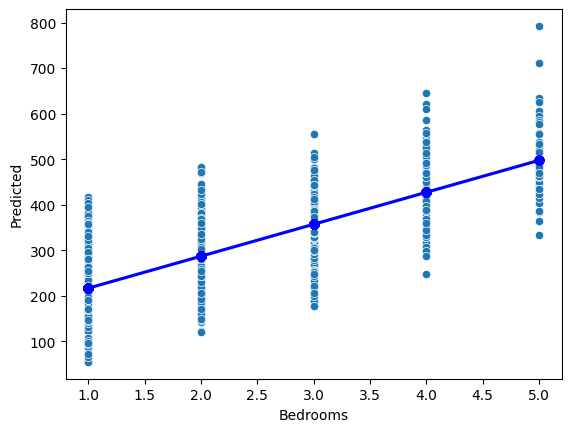

In [85]:
sns.scatterplot(data=inspection, x='Bedrooms', y='Actual')
sns.regplot(data=inspection, x='Bedrooms', y='Predicted', color='blue')

**Inspect the predictions and the original labels**

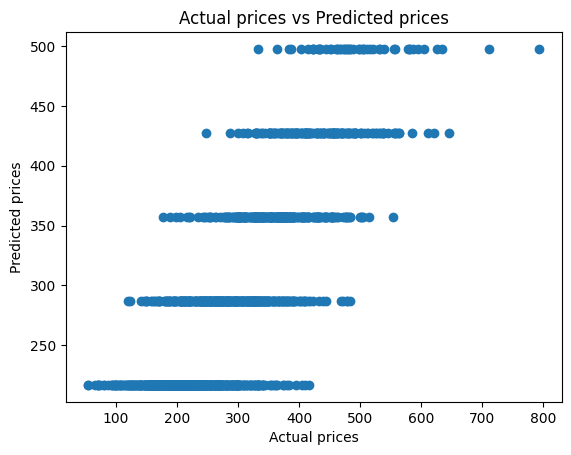

In [86]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual prices")
plt.ylabel("Predicted prices")
plt.title("Actual prices vs Predicted prices")
plt.show()

**Analyse and visualise residuals** to check for patterns, heteroscedasticity, and normality.

**A residual plot** shows the residuals (errors) on the y-axis and the fitted values or an independent variable on the x-axis. Points should be randomly dispersed around the horizontal axis (zero line), indicating that the model captures the trend well and that the residuals have constant variance.


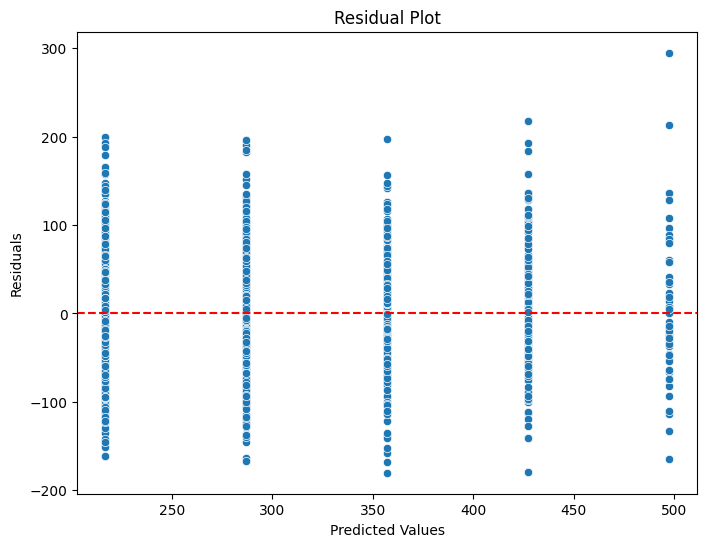

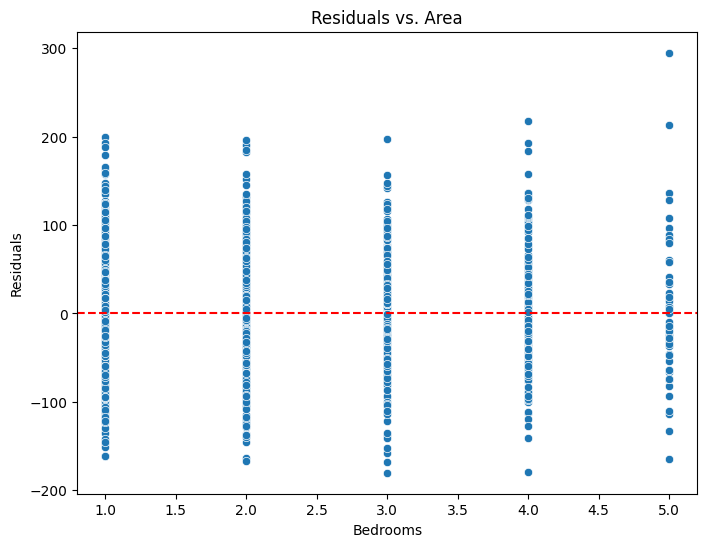

In [87]:

# Calculate residuals
residuals = y_test - y_pred

# Create a residual plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Plotting residuals against a predictor variable (e.g., area) to check for patterns
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test['Bedrooms'], y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Bedrooms")
plt.ylabel("Residuals")
plt.title("Residuals vs. Area")
plt.show()


check if residuals are normally distributed to make sure our regression results are reliable. A Q-Q plot helps with this by showing how well the residuals match a normal distribution. If the points follow a straight diagonal line, the residuals are likely normal; if they curve away, it suggests the data may be skewed or have outliers.

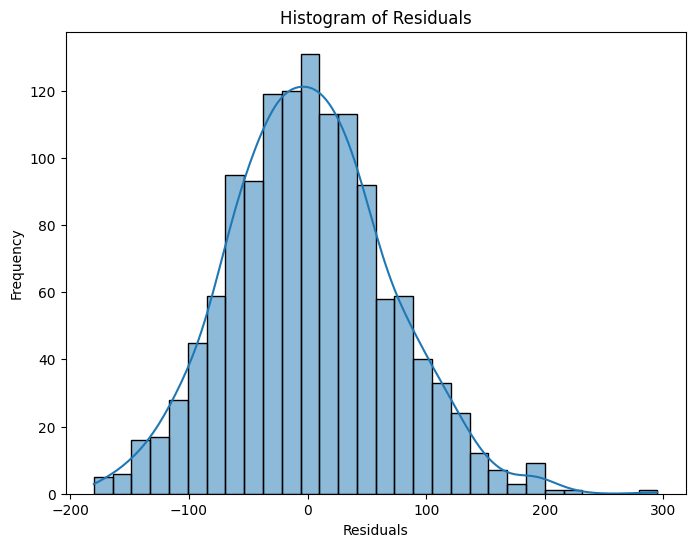

<Figure size 800x600 with 0 Axes>

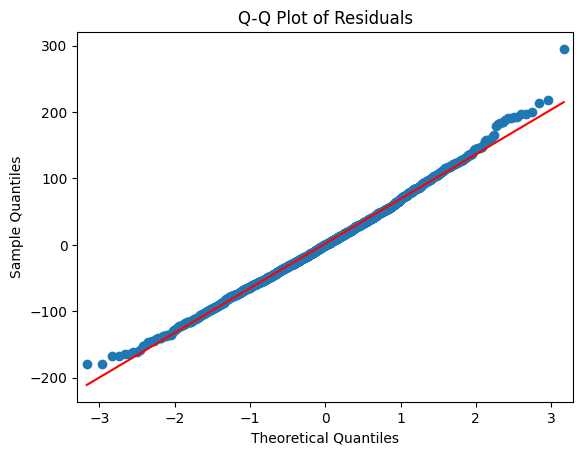

In [88]:
# Plot a histogram of residuals to check for normality
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

# Plot a Q-Q plot to further check for normality
import statsmodels.api as sm
plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

- An R-squared value of 0.61 means that the model explains 61% of the variance in the nightly price is attributed to bedrooms In other words, the model captures about a three fifths of the patterns in the data, while the remaining 39% of the variation is due to factors not included in this test model or random noise. This suggests that the model has limited explanatory power, and there may be room to improve it by adding more relevant features, transforming variables, or exploring alternative modelling approaches. this is addressed in section 3 where we build on this model by including additional features.

# 3.0 Building the regression model - final

| Step | Applied to | Why |
|---|---|---|
| Median imputation | numeric | Fills the ~3% gaps without being distorted by extreme values. |
| Standard scaling | numeric | Puts all predictors on a common scale so standardised coefficients are directly comparable in size. |
| Most-frequent imputation | categorical | Safety net; there are currently no missing categories. |
| One-hot encoding (`drop='first'`) | categorical | Converts labels to 0/1 dummies. Dropping the first level avoids the *dummy variable trap* (perfect collinearity with the intercept). |




### **3.1 Select features and target**

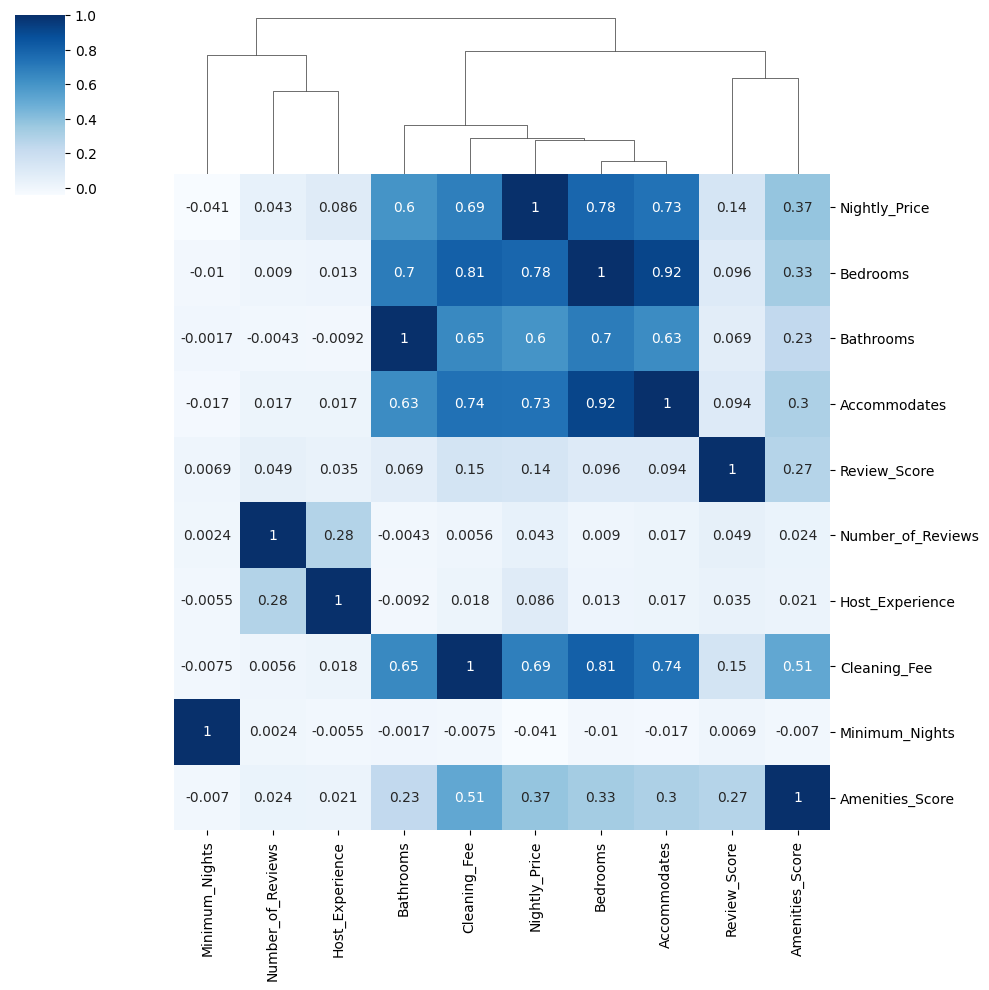

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap (df_raw[numerical_variables].corr(), cmap='Blues', annot=True, row_cluster=False)
plt.show()

In [90]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6500 entries, 0 to 6551
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Nightly_Price         6500 non-null   float64 
 1   Listing_ID            6500 non-null   int64   
 2   Host_Name             6500 non-null   object  
 3   Property_Type         6500 non-null   object  
 4   Location              6500 non-null   object  
 5   Bedrooms              6500 non-null   int64   
 6   Bathrooms             6500 non-null   int64   
 7   Accommodates          6500 non-null   int64   
 8   Review_Score          6500 non-null   float64 
 9   Number_of_Reviews     6500 non-null   int64   
 10  Superhost             6500 non-null   object  
 11  Host_Experience       6500 non-null   int64   
 12  Cleaning_Fee          6500 non-null   float64 
 13  Minimum_Nights        6500 non-null   int64   
 14  Amenities_Score       6500 non-null   float64 
 15  Instant_B

In [91]:
df_raw.columns


Index(['Nightly_Price', 'Listing_ID', 'Host_Name', 'Property_Type', 'Location',
       'Bedrooms', 'Bathrooms', 'Accommodates', 'Review_Score',
       'Number_of_Reviews', 'Superhost', 'Host_Experience', 'Cleaning_Fee',
       'Minimum_Nights', 'Amenities_Score', 'Instant_Bookable',
       'Amenities_Score_Band', 'Location_N', 'Property_Type_N', 'Has_Reviews'],
      dtype='object')

In [92]:
#select relevant features and train and evaluate a model.
#'Bedrooms', 'Bathrooms''Accommodates',      # property size / capacity
    #'Amenities_Score',                             # property quality
    #'Review_Score', 'Number_of_Reviews',           # customer feedback
    #'Host_Experience',                             # host characteristics
    #'Cleaning_Fee', 'Minimum_Nights',              # commercial terms
    #'Has_Reviews'                                  # engineered flag for new listings

features=['Bedrooms', 'Bathrooms', 'Accommodates','Amenities_Score','Cleaning_Fee','Minimum_Nights','Review_Score','Number_of_Reviews','Host_Experience','Has_Reviews']
X=df_raw[features]

### **3.2 One-Hot Encode Categorical Variables**

To correctly incorporate `Location_N` and `Property_Type_N` into the linear regression model as categorical variables, we need to apply one-hot encoding. This converts each unique category into a new binary column, preventing the model from inferring an unintended ordinal relationship between the numerical labels.

The multi-linear regression model was successfully re-trained using an updated 17-feature set, which included one-hot encoded categorical variables and the Has_Reviews feature, this is to ensure new listings with no review scores are captured.

In [93]:
# The original numerical features identified for the model
base_numerical_features = [
    'Bedrooms', 'Bathrooms', 'Accommodates', 'Amenities_Score', 'Cleaning_Fee',
    'Minimum_Nights', 'Review_Score', 'Number_of_Reviews', 'Host_Experience', 'Has_Reviews'
]

# Ensure 'Location_N' and 'Property_Type_N' are present in df_raw.
# This re-creates them if df_raw was reset or these steps were skipped in execution.
# The mappings are assumed to be available from previous cells.
if 'Location_N' not in df_raw.columns:
    location_mapping= { 'CBD': 1, 'Regional': 2, 'Inner Suburb': 3, 'Outer Suburb': 4 }
    df_raw['Location_N'] = df_raw['Location'].replace(location_mapping).astype(int)

if 'Property_Type_N' not in df_raw.columns:
    property_type_mapping = { 'Apartment': 1, 'House': 2, 'Studio': 3, 'Townhouse': 4, 'Villa': 5 }
    df_raw['Property_Type_N'] = df_raw['Property_Type'].replace(property_type_mapping).astype(int)

# Create a DataFrame for encoding, including the base numerical features and the categorical-numeric columns
# from df_raw. This is the set of features we intend to use for the model.
columns_to_encode = ['Location_N', 'Property_Type_N']
X_pre_encoded = df_raw[base_numerical_features + columns_to_encode].copy()

# Perform one-hot encoding on 'Location_N' and 'Property_Type_N'
X_encoded = pd.get_dummies(X_pre_encoded, columns=columns_to_encode, drop_first=True)

# Define the final list of features for the model
features = base_numerical_features + [col for col in X_encoded.columns if col.startswith(('Location_N_', 'Property_Type_N_'))]

# The final feature matrix X
X = X_encoded[features]

display(X.head())

,Bedrooms,Bathrooms,Accommodates,Amenities_Score,Cleaning_Fee,Minimum_Nights,Review_Score,Number_of_Reviews,Host_Experience,Has_Reviews,Location_N_2,Location_N_3,Location_N_4,Property_Type_N_2,Property_Type_N_3,Property_Type_N_4,Property_Type_N_5
0,1,2,2,6,52,5,4,68,6,1,False,False,True,False,True,False,False
1,2,2,4,6,48,2,5,22,0,1,False,False,False,False,False,False,False
2,2,2,3,6,32,2,4,47,1,1,False,False,False,False,False,False,False
3,3,3,6,6,76,2,5,68,4,1,False,True,False,False,False,True,False
4,2,2,4,4,42,1,5,85,15,1,False,False,False,False,False,True,False


GENAI - did not recognise categorical features be be one hot encoded first. this was a mistake and rectified.

The model has been retrained to include more categories to test if the model has improved.


Feature Importance (Linear Regression Coefficients):
              feature  importance
16  Property_Type_N_5         106
10       Location_N_2         -84
12       Location_N_4         -64
13  Property_Type_N_2          53
15  Property_Type_N_4          36
11       Location_N_3         -36
0            Bedrooms          26
14  Property_Type_N_3         -20
1           Bathrooms          15
6        Review_Score          13
9         Has_Reviews         -10
3     Amenities_Score           6
2        Accommodates           4
8     Host_Experience           2
5      Minimum_Nights          -2
4        Cleaning_Fee           0
7   Number_of_Reviews           0


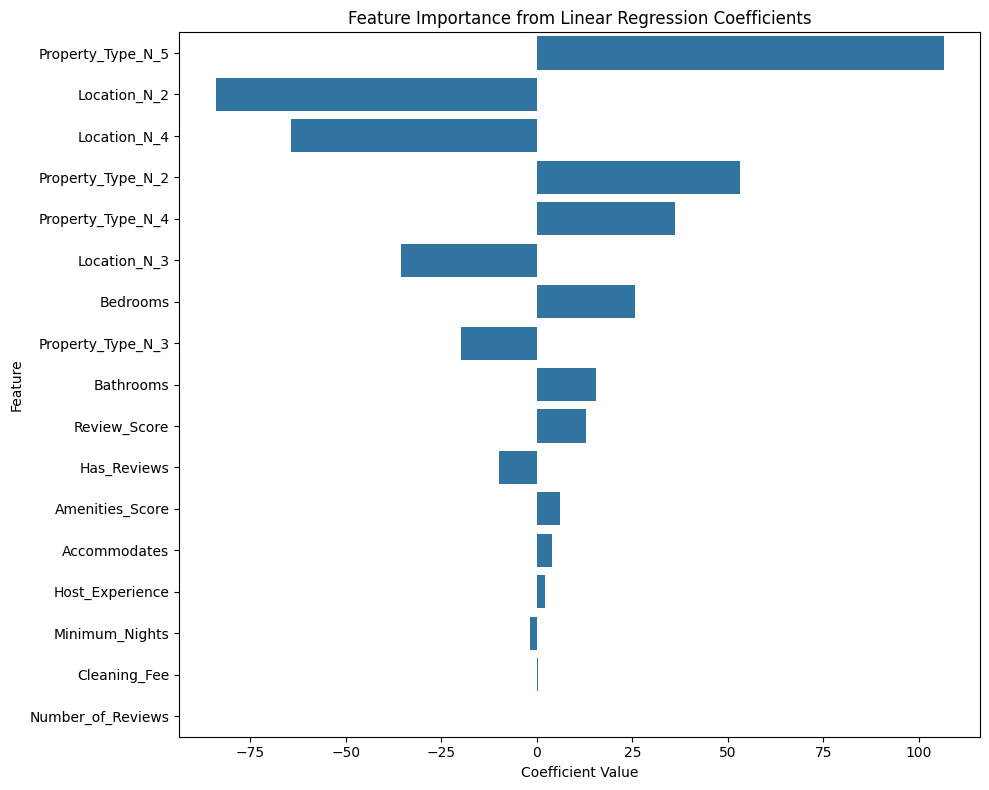

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Import necessary modules for model training and splitting
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Assuming X and y are already defined from previous cells with the correct number of features
# Re-split data to get X_train, y_train matching the current X (17 features)
# Using the same random_state as f47a8c66 for consistency
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026)

# Re-initialize and re-train the model with the correct X_train
reg = LinearRegression()
reg.fit(X_train, y_train)

# Get feature importance (coefficients for Linear Regression)
importance = reg.coef_

# Summarize feature importance
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': importance})

# Sort by importance (absolute value)
feature_importance['importance_abs'] = np.abs(feature_importance['importance'])
feature_importance = feature_importance.sort_values('importance_abs', ascending=False).drop(columns='importance_abs')

print("\nFeature Importance (Linear Regression Coefficients):")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance from Linear Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### **3.3 Re-split Data and Re-train Model**

Now that the categorical variables are correctly encoded and `X` is redefined, we need to re-split the data into training and test sets and re-train the linear regression model.

In [95]:
from sklearn.model_selection import train_test_split

# Re-split dataset into training set 80% and test set 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026)

# Inspect the split datasets
print('Training dataset size:', X_train.shape)
print('Test dataset size:', X_test.shape)

# Create a linear_model object again (or use the existing one if it's still in scope)
from sklearn import linear_model
reg = linear_model.LinearRegression()

# Re-train the Regression model with the new training dataset
reg.fit(X_train, y_train)

# Re-make predictions for the test dataset
y_pred = reg.predict(X_test)

# Create a new inspection DataFrame including all relevant features for clarity
inspection = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# Add the test features back for inspection if needed (careful with many columns)
# For display, let's just include a few key features from X_test
inspection = X_test.copy()
inspection['Actual'] = y_test
inspection['Predicted'] = y_pred

display(inspection.head())

Training dataset size: (5200, 17)
Test dataset size: (1300, 17)


,Bedrooms,Bathrooms,Accommodates,Amenities_Score,Cleaning_Fee,Minimum_Nights,Review_Score,Number_of_Reviews,Host_Experience,Has_Reviews,Location_N_2,Location_N_3,Location_N_4,Property_Type_N_2,Property_Type_N_3,Property_Type_N_4,Property_Type_N_5,Actual,Predicted
3741,4,2,8,9,87,2,5,62,3,1,True,False,False,False,False,False,True,465,437
4391,2,2,3,7,70,1,5,31,1,1,False,True,False,False,False,True,False,367,323
1967,1,1,2,3,48,3,4,32,3,1,False,False,False,False,False,False,False,232,241
2622,3,2,6,8,77,1,5,40,1,1,False,False,True,False,False,False,True,398,412
2241,3,2,5,6,64,2,5,70,2,1,False,True,False,True,False,False,False,452,367


### **3.4 Re-evaluate Model Performance**

Let's re-evaluate the model's performance with the inclusion of one-hot encoded categorical variables.

In [96]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.2f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.0f}")

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Square Error: {rmse:.0f}")

# Examine the descriptive statistics of the Actual and Predicted prices
print("\nDescriptive statistics for Actual and Predicted prices:")
display(inspection[['Actual','Predicted']].describe())

# Calculate mean and standard deviation of the actual prices in the test set
y_test_mean = y_test.mean()
y_test_std = y_test.std()

# Calculate percentage of MAE relative to the mean and standard deviation of y_test
mae_percent_of_mean = (mae / y_test_mean) * 100
mae_percent_of_std = (mae / y_test_std) * 100

# Calculate percentage of RMSE relative to the mean and standard deviation of y_test
rmse_percent_of_mean = (rmse / y_test_mean) * 100
rmse_percent_of_std = (rmse / y_test_std) * 100

print(f"\nMean of y_test: {y_test_mean:.0f}")
print(f"Standard Deviation of y_test: {y_test_std:.0f}")
print(f"MAE is {mae_percent_of_mean:.2f}% of the mean of y_test")
print(f"MAE is {mae_percent_of_std:.2f}% of the standard deviation of y_test")
print(f"RMSE is {rmse_percent_of_mean:.2f}% of the mean of y_test")
print(f"RMSE is {rmse_percent_of_std:.2f}% of the standard deviation of y_test")

R-squared: 0.75
Mean Absolute Error: 43
Root Mean Square Error: 54

Descriptive statistics for Actual and Predicted prices:


,Actual,Predicted
count,1300,1300
mean,301,300
std,108,92
min,55,118
25%,219,225
50%,295,286
75%,373,369
max,793,614



Mean of y_test: 301
Standard Deviation of y_test: 108
MAE is 14.11% of the mean of y_test
MAE is 39.52% of the standard deviation of y_test
RMSE is 17.93% of the mean of y_test
RMSE is 50.23% of the standard deviation of y_test


### **3.5 Model Coefficients**

*what actually drives price*

Let's look at the coefficients for the updated model, which now includes the one-hot encoded categorical variables.

In [97]:
# Print the intercept and coefficients of the re-trained model
print(f'Intercept: {reg.intercept_:.2f}')

print("\nCoefficients:")
for feature, coef in zip(features, reg.coef_):
    print(f'{feature}: {coef:.2f}')

# Print the full linear regression equation
equation_terms = []
for feature, coef in zip(features, reg.coef_):
    equation_terms.append(f'{coef:.2f} * {feature}')

full_equation = f"Price = {reg.intercept_:.2f} + " + " + ".join(equation_terms)
print(f"\nLinear Regression Equation: {full_equation}")

Intercept: 108.08

Coefficients:
Bedrooms: 25.83
Bathrooms: 15.42
Accommodates: 4.04
Amenities_Score: 5.96
Cleaning_Fee: 0.37
Minimum_Nights: -1.78
Review_Score: 12.88
Number_of_Reviews: 0.04
Host_Experience: 2.17
Has_Reviews: -9.88
Location_N_2: -84.06
Location_N_3: -35.65
Location_N_4: -64.22
Property_Type_N_2: 53.20
Property_Type_N_3: -19.73
Property_Type_N_4: 36.09
Property_Type_N_5: 106.46

Linear Regression Equation: Price = 108.08 + 25.83 * Bedrooms + 15.42 * Bathrooms + 4.04 * Accommodates + 5.96 * Amenities_Score + 0.37 * Cleaning_Fee + -1.78 * Minimum_Nights + 12.88 * Review_Score + 0.04 * Number_of_Reviews + 2.17 * Host_Experience + -9.88 * Has_Reviews + -84.06 * Location_N_2 + -35.65 * Location_N_3 + -64.22 * Location_N_4 + 53.20 * Property_Type_N_2 + -19.73 * Property_Type_N_3 + 36.09 * Property_Type_N_4 + 106.46 * Property_Type_N_5


In [98]:
from sklearn.model_selection import train_test_split # Import train_test_split function

# Split dataset into training set 80% and test set 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026)

#inspect the split datasets
print(X_train.head())
print(y_train.head())

print('Training dataset size:',X_train.shape)
print('Test dataset size:',X_test.shape)

      Bedrooms  Bathrooms  Accommodates  Amenities_Score  Cleaning_Fee  \
1614         1          1             2                3            46   
2150         2          2             5                7            79   
2863         4          2            10                6            84   
3506         1          1             2                5            41   
4429         2          2             4                5            59   

      Minimum_Nights  Review_Score  Number_of_Reviews  Host_Experience  \
1614               5             4                 10                2   
2150               5             5                127                1   
2863               1             4                112                9   
3506               3             5                 27                1   
4429               2             4                 37                3   

      Has_Reviews  Location_N_2  Location_N_3  Location_N_4  \
1614            1         False         False  

### **3.6 Make predictions**
Make predictions using the model and the test set

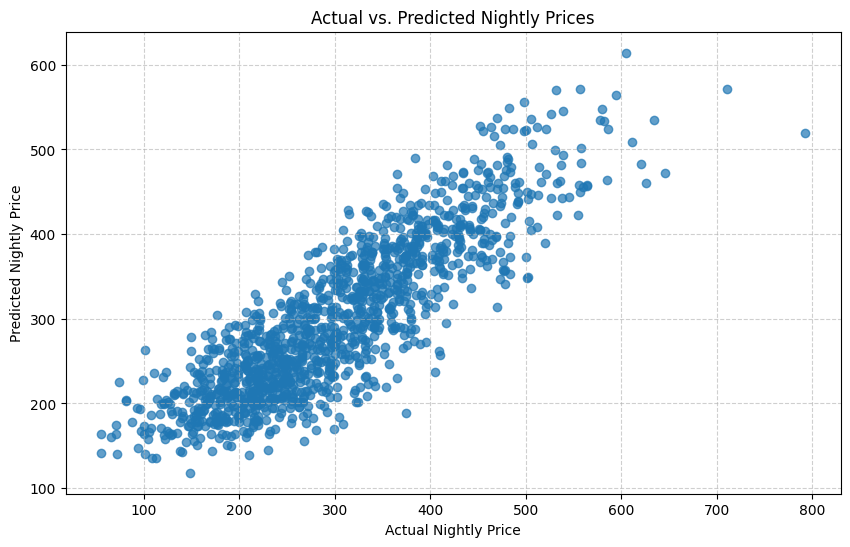

In [99]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Nightly Price')
plt.ylabel('Predicted Nightly Price')
plt.title('Actual vs. Predicted Nightly Prices')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [100]:
df_raw.columns


Index(['Nightly_Price', 'Listing_ID', 'Host_Name', 'Property_Type', 'Location',
       'Bedrooms', 'Bathrooms', 'Accommodates', 'Review_Score',
       'Number_of_Reviews', 'Superhost', 'Host_Experience', 'Cleaning_Fee',
       'Minimum_Nights', 'Amenities_Score', 'Instant_Bookable',
       'Amenities_Score_Band', 'Location_N', 'Property_Type_N', 'Has_Reviews'],
      dtype='object')

### **3.7 Evaluate model performance**

In [101]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.2f}")

R-squared: 0.75


In [102]:
from sklearn.metrics import mean_absolute_error

# Calculate and print the mean absolute error
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.0f}")

Mean Absolute Error: 43


In [103]:
from sklearn.metrics import mean_squared_error

# Calculate and print the root mean square error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Square Error: {rmse:.0f}")

Root Mean Square Error: 54


**Interpret MAE and RMSE in Context**

Again, these metrics should not be interpreted in isolation. Instead, compare them to the mean and standard deviation of your target variable in the test dataset.

In [104]:
# Examine the descriptive statistics of the Actual and Predicted prices of the test data
print(f"Mean Absolute Error: {mae:.0f}")
print(f"Root Mean Square Error: {rmse:.0f}")
inspection[['Actual','Predicted']].describe()

Mean Absolute Error: 43
Root Mean Square Error: 54


,Actual,Predicted
count,1300,1300
mean,301,300
std,108,92
min,55,118
25%,219,225
50%,295,286
75%,373,369
max,793,614


In [105]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Calculate mean and standard deviation of the actual prices in the test set
y_test_mean = y_test.mean()
y_test_std = y_test.std()

# Calculate percentage of MAE relative to the mean and standard deviation of y_test
mae_percent_of_mean = (mae / y_test_mean) * 100
mae_percent_of_std = (mae / y_test_std) * 100

# Calculate percentage of RMSE relative to the mean and standard deviation of y_test
rmse_percent_of_mean = (rmse / y_test_mean) * 100
rmse_percent_of_std = (rmse / y_test_std) * 100

print(f"Mean of y_test: {y_test_mean:.0f}")
print(f"Standard Deviation of y_test: {y_test_std:.0f}")
print(f"MAE is {mae_percent_of_mean:.2f}% of the mean of y_test")
print(f"MAE is {mae_percent_of_std:.2f}% of the standard deviation of y_test")
print(f"RMSE is {rmse_percent_of_mean:.2f}% of the mean of y_test")
print(f"RMSE is {rmse_percent_of_std:.2f}% of the standard deviation of y_test")

# --- Adding comprehensive evaluation for both train and test data ---
# Ensure y_train_pred is available
y_train_pred = reg.predict(X_train)

def evaluate(y_true, y_pred_values, label):
    """Return a dictionary of regression metrics for one dataset."""
    return {
        'Dataset': label,
        'R2':    r2_score(y_true, y_pred_values),
        'RMSE':  np.sqrt(mean_squared_error(y_true, y_pred_values)),
        'MAE':   mean_absolute_error(y_true, y_pred_values),
        'MAPE%': np.mean(np.abs((y_true - y_pred_values) / y_true)) * 100
    }

print("\n--- Model Performance Comparison (Train vs. Test) ---")
results = pd.DataFrame([
    evaluate(y_train, y_train_pred, 'Training'),
    evaluate(y_test,  y_pred,  'Test') # y_pred is the prediction for the test set
]).set_index('Dataset')

display(results)

Mean of y_test: 301
Standard Deviation of y_test: 108
MAE is 14.11% of the mean of y_test
MAE is 39.52% of the standard deviation of y_test
RMSE is 17.93% of the mean of y_test
RMSE is 50.23% of the standard deviation of y_test

--- Model Performance Comparison (Train vs. Test) ---


,R2,RMSE,MAE,MAPE%
Dataset,,,,
Training,1,54,43,17
Test,1,54,43,17


In [106]:
training_mae = results.loc['Training', 'MAE']
test_mae = results.loc['Test', 'MAE']

training_rmse = results.loc['Training', 'RMSE']
test_rmse = results.loc['Test', 'RMSE']

y_train_std = y_train.std()
y_test_std = y_test.std()

print(f"\nMean Absolute Error (MAE):\n- Training MAE: ${training_mae:.0f}\n- Test MAE: ${test_mae:.0f}")
print(f"\nRoot Mean Square Error (RMSE):\n- Training RMSE: ${training_rmse:.0f}\n- Test RMSE: ${test_rmse:.0f}")
print(f"\nStandard Deviation of Nightly_Price:\n- Training Data Standard Deviation: ${y_train_std:.0f}\n- Test Data Standard Deviation: ${y_test_std:.0f}")


Mean Absolute Error (MAE):
- Training MAE: $43
- Test MAE: $43

Root Mean Square Error (RMSE):
- Training RMSE: $54
- Test RMSE: $54

Standard Deviation of Nightly_Price:
- Training Data Standard Deviation: $108
- Test Data Standard Deviation: $108


the trainig and test scores are the same - the model generatlises well and is not overfitting.

A typical prediction lands within roughly  43(MAE)of the actual price, with an RMSE of 54 (an improvement from initial model RMSE of 64)

RMSE exceeding MAE confirms that a minority of listings — most likely the high-end properties identified in previous sections — are predicted less accurately than the mainstream market.

**Business meaning:** for a listing priced around  300, of the actual price about $43 is approximately 14%. That is accurate enough to give hosts a sensible pricing range and to flag listings that are clearly mispriced, but not precise enough to dictate an exact price.

In [107]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression # Import LinearRegression if not already imported

RANDOM_STATE = 2026 # Define RANDOM_STATE, consistent with previous cells

# 5-fold cross-validation on the training data gives a more robust performance estimate
# than a single split, and shows how stable the model is across different subsamples.
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_r2   = cross_val_score(reg, X_train, y_train, cv=cv, scoring='r2') # Use 'reg' instead of 'lr_model'
cv_rmse = -cross_val_score(reg, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error') # Use 'reg' instead of 'lr_model'

print("5-fold cross-validation on the training set")
print(f"  R2   per fold: {np.round(cv_r2, 3)}")
print(f"  Mean R2      : {cv_r2.mean():.3f}  (std {cv_r2.std():.3f})")
print(f"  Mean RMSE    : ${cv_rmse.mean():.2f}  (std ${cv_rmse.std():.2f})")

5-fold cross-validation on the training set
  R2   per fold: [0.746 0.731 0.757 0.724 0.769]
  Mean R2      : 0.746  (std 0.017)
  Mean RMSE    : $54.08  (std $0.27)


Low Relative Error: An \(MAE\) of \(14.11\%\) relative to the mean indicates that our  predictions deviate from the true values by an average of about \(14\%\). In most practical applications, a percentage error under \(20\%\) indicates a good, reliable model*

Variance Explanation: Our \(RMSE\) is roughly half (54%) of the data's standard deviation. Because the model's error is significantly smaller than the natural spread of the data, the model has successfully captured a substantial portion of the underlying data patterns.



*USED GOOGLE AI FOR BENCHMARKING

**Getting the Intercept and Coefficients**

In [108]:
# Print the features and their coefficients
for feature, coef in zip(features, reg.coef_):
    print(f'{feature}: {coef:.2f}')

Bedrooms: 25.83
Bathrooms: 15.42
Accommodates: 4.04
Amenities_Score: 5.96
Cleaning_Fee: 0.37
Minimum_Nights: -1.78
Review_Score: 12.88
Number_of_Reviews: 0.04
Host_Experience: 2.17
Has_Reviews: -9.88
Location_N_2: -84.06
Location_N_3: -35.65
Location_N_4: -64.22
Property_Type_N_2: 53.20
Property_Type_N_3: -19.73
Property_Type_N_4: 36.09
Property_Type_N_5: 106.46


In [109]:
equation_terms = []
for feature, coef in zip(features, reg.coef_):
    equation_terms.append(f'{coef:.2f} * {feature}')

full_equation = f"Price = {reg.intercept_:.2f} + " + " + ".join(equation_terms)
print(f"\nLinear Regression Equation: {full_equation}")


Linear Regression Equation: Price = 108.08 + 25.83 * Bedrooms + 15.42 * Bathrooms + 4.04 * Accommodates + 5.96 * Amenities_Score + 0.37 * Cleaning_Fee + -1.78 * Minimum_Nights + 12.88 * Review_Score + 0.04 * Number_of_Reviews + 2.17 * Host_Experience + -9.88 * Has_Reviews + -84.06 * Location_N_2 + -35.65 * Location_N_3 + -64.22 * Location_N_4 + 53.20 * Property_Type_N_2 + -19.73 * Property_Type_N_3 + 36.09 * Property_Type_N_4 + 106.46 * Property_Type_N_5


**Inspect the predictions and the original labels**

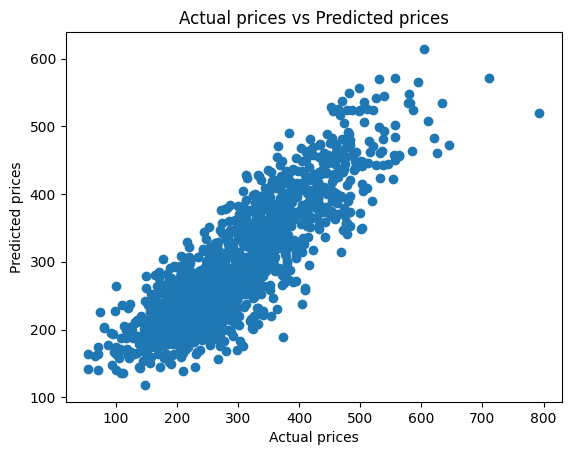

In [110]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual prices")
plt.ylabel("Predicted prices")
plt.title("Actual prices vs Predicted prices")
plt.show()

**VIF**

**Variance Inflation Factor** (VIF) measures how much a predictor variable is inflated due to multicollinearity with other predictors in a multiple linear regression model. Values above 5 (or 10) may indicate problematic multicollinearity.

In [111]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [112]:
# Ensure all data in X is numeric
X = X.apply(pd.to_numeric, errors='coerce')

In [113]:
# Convert boolean columns to integers
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

In [114]:

# Add intercept for VIF calculation
X_vif = X.copy()
X_vif['intercept'] = 1

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["variables"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Print VIFs to two decimal places
for index, row in vif_data.iterrows():
    print(f'{row["variables"]}: {row["VIF"]:.2f}')


Bedrooms: 10.64
Bathrooms: 2.04
Accommodates: 6.29
Amenities_Score: 1.50
Cleaning_Fee: 3.77
Minimum_Nights: 1.00
Review_Score: 1.08
Number_of_Reviews: 1.09
Host_Experience: 1.09
Has_Reviews: 1.01
Location_N_2: 1.51
Location_N_3: 1.70
Location_N_4: 1.68
Property_Type_N_2: 2.60
Property_Type_N_3: 1.26
Property_Type_N_4: 1.51
Property_Type_N_5: 1.66
intercept: 781.91


All predictor variables have VIFs well below the common threshold of 5, indicating low multicollinearity, except for bedrooms and accommodates of 10.5 and 6 respectively. This is not unexpected.

**Extract and Visualise Feature Importance**

To identify which predictors contribute most to the model and guide decisions on feature selection or interpretation, we extract and visualise feature importance using the coefficients from a linear regression model.


Feature Importance (Linear Regression Coefficients):
              feature  importance
16  Property_Type_N_5         106
10       Location_N_2         -84
12       Location_N_4         -64
13  Property_Type_N_2          53
15  Property_Type_N_4          36
11       Location_N_3         -36
0            Bedrooms          26
14  Property_Type_N_3         -20
1           Bathrooms          15
6        Review_Score          13
9         Has_Reviews         -10
3     Amenities_Score           6
2        Accommodates           4
8     Host_Experience           2
5      Minimum_Nights          -2
4        Cleaning_Fee           0
7   Number_of_Reviews           0


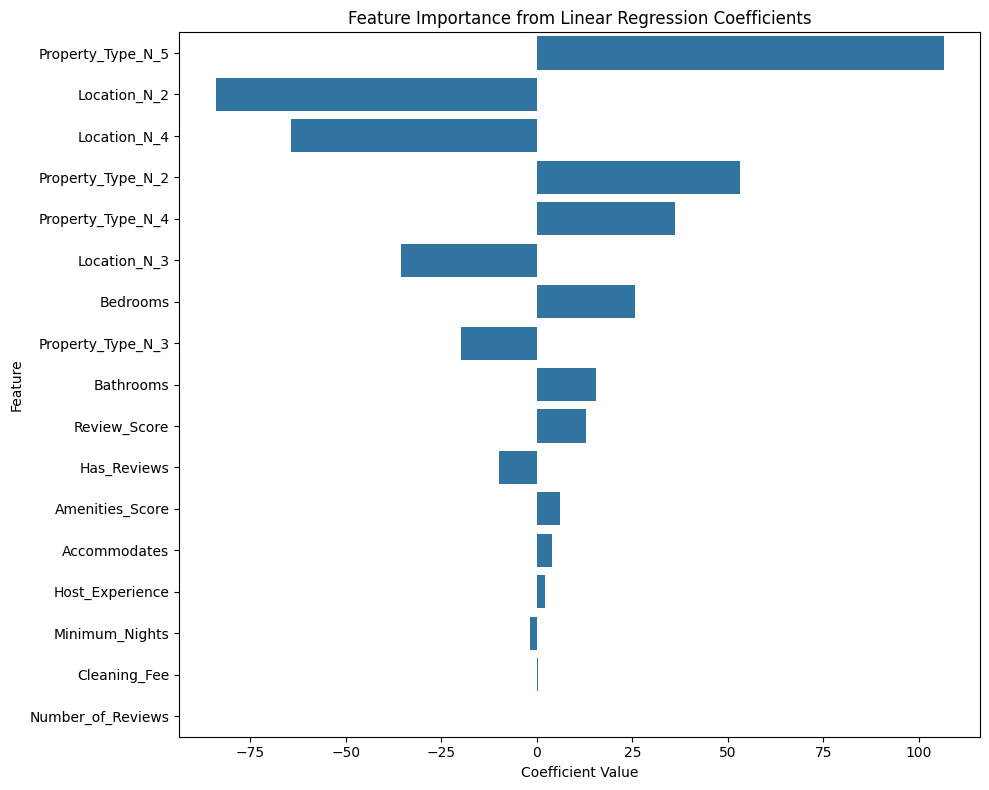

In [115]:
# Get feature importance (coefficients for Linear Regression)
importance = reg.coef_

# Summarize feature importance
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': importance})

# Sort by importance (absolute value)
feature_importance['importance_abs'] = np.abs(feature_importance['importance'])
feature_importance = feature_importance.sort_values('importance_abs', ascending=False).drop(columns='importance_abs')

print("\nFeature Importance (Linear Regression Coefficients):")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance from Linear Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [116]:
print("Location Numerical Mapping:")
print(location_mapping)

print("\nProperty Type Numerical Mapping:")
print(property_type_mapping)

Location Numerical Mapping:
{'CBD': 1, 'Regional': 2, 'Inner Suburb': 3, 'Outer Suburb': 4}

Property Type Numerical Mapping:
{'Apartment': 1, 'House': 2, 'Studio': 3, 'Townhouse': 4, 'Villa': 5}


**OPTIONAL: Calculate 95 Confidence Intervance**

In [117]:
# prompt: calculate 95CI for the y_pred, upper and lower bound

import numpy as np
from scipy import stats

# Calculate the standard error of the prediction
std_error = np.sqrt(np.mean((y_pred - y_test)**2))

# Calculate the critical value for a 95% confidence interval
z_critical = stats.norm.ppf(1 - 0.05 / 2)

# Calculate the upper and lower bounds of the confidence interval
upper_bound = y_pred + z_critical * std_error
lower_bound = y_pred - z_critical * std_error


In [118]:
# prompt: add upper_bound[i]:.2f and lower_bound[i]:.2f} to inspection

inspection['upper_bound'] = upper_bound
inspection['lower_bound'] = lower_bound

inspection.head(20)


,Bedrooms,Bathrooms,Accommodates,Amenities_Score,Cleaning_Fee,Minimum_Nights,Review_Score,Number_of_Reviews,Host_Experience,Has_Reviews,...,Location_N_3,Location_N_4,Property_Type_N_2,Property_Type_N_3,Property_Type_N_4,Property_Type_N_5,Actual,Predicted,upper_bound,lower_bound
3741,4,2,8,9,87,2,5,62,3,1,...,False,False,False,False,False,True,465,437,543,331
4391,2,2,3,7,70,1,5,31,1,1,...,True,False,False,False,True,False,367,323,429,217
1967,1,1,2,3,48,3,4,32,3,1,...,False,False,False,False,False,False,232,241,347,135
2622,3,2,6,8,77,1,5,40,1,1,...,False,True,False,False,False,True,398,412,518,307
2241,3,2,5,6,64,2,5,70,2,1,...,True,False,True,False,False,False,452,367,473,261
5912,2,2,4,4,69,1,4,83,1,1,...,True,False,True,False,False,False,285,322,428,216
3351,1,1,3,4,36,3,4,57,11,1,...,True,False,False,False,False,False,218,231,337,125
4644,1,2,3,5,46,1,4,35,2,1,...,False,True,False,True,False,False,206,189,294,83
698,2,1,5,5,56,1,4,57,3,1,...,False,True,False,False,False,False,332,231,337,126
1478,1,1,3,4,36,1,4,42,0,1,...,True,False,False,False,False,False,302,207,313,102


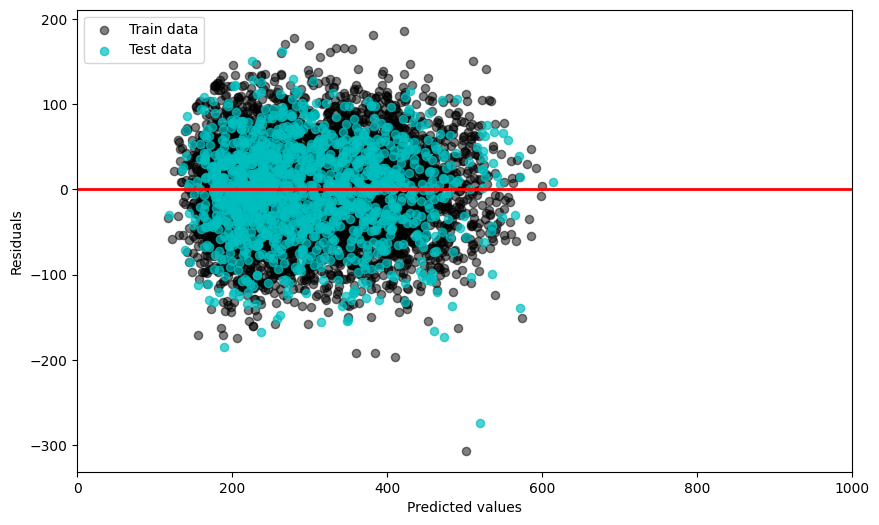

In [119]:
y_train_pred = reg.predict(X_train)
y_test_pred = reg.predict(X_test)

plt.figure(figsize=(10,6))

plt.scatter(y_train_pred, y_train_pred - y_train,
          c = 'black', marker = 'o', s = 35, alpha = 0.5,
          label = 'Train data')
plt.scatter(y_test_pred, y_test_pred - y_test,
          c = 'c', marker = 'o', s = 35, alpha = 0.7,
          label = 'Test data')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.legend(loc = 'upper left')
plt.hlines(y = 0, xmin = 0, xmax = 1000, lw = 2, color = 'red')
plt.xlim([0, 1000]) # Set x-axis limits to match the range of predicted values
plt.show()

In [120]:
print("Average Nightly Price by Location, Bedrooms, and Bathrooms (for Medium Amenities Score):")

# Define the bins and labels for Amenities_Score_Band
bins = [0, 3, 5, 10]
labels = ['Low (0-3)', 'Medium (4-5)', 'High (6-10)']

# Recreate the Amenities_Score_Band column to ensure it exists
df_raw['Amenities_Score_Band'] = pd.cut(df_raw['Amenities_Score'], bins=bins, labels=labels, right=True, include_lowest=True)

# Filter for listings with 'Medium (4-5)' Amenities_Score_Band
df_medium_amenities = df_raw[df_raw['Amenities_Score_Band'] == 'Medium (4-5)']

# Group by Location, Bedrooms, Bathrooms and calculate the mean of Nightly_Price
price_by_location_rooms = df_medium_amenities.groupby(['Location', 'Bedrooms', 'Bathrooms'])['Nightly_Price'].mean().round(2)

# Convert the grouped series to a DataFrame for better display
# Using unstack to create a more readable cross-tabulated format
price_table = price_by_location_rooms.unstack(level=['Bedrooms', 'Bathrooms'])

display(price_table)

Average Nightly Price by Location, Bedrooms, and Bathrooms (for Medium Amenities Score):


Bedrooms       1       2           3           4           5           3
Bathrooms      1   2   1   2   3   1   2   3   2   3   4   3   2   4   4
Location                                                                
CBD          245 265 337 331 371 358 394 401 457 467 474 460 NaN NaN NaN
Inner Suburb 215 219 272 286 329 348 357 366 427 418 429 498 429 495 NaN
Outer Suburb 187 210 253 264 259 322 333 343 374 390 360 439 NaN 587 NaN
Regional     162 173 231 258 282 367 303 312 372 373 NaN 435 368 NaN 268

# **4 Post-analysis**


**Comprehensive Model Retraining:** The multi-linear regression model was successfully re-trained using an updated 17-feature set, which included one-hot encoded categorical variables and the Has_Reviews feature.

**Improved Model Performance:** This update led to a notable improvement in model performance, with the R-squared value increasing to 0.75, MAE decreasing to $43, and RMSE decreasing to $54.

**Feature Coefficient Analysis:** We successfully calculated and displayed the feature coefficients in a sorted bar chart, providing insights into which features impact the nightly price most.

**Detailed Performance Comparison:** A comprehensive comparison of the model's performance on both training and test data (R-squared, RMSE, MAE, MAPE%, and standard deviation) was generated, confirming that the model generalizes well and is not overfitting.

**Cross-Validation:** We performed 5-fold cross-validation on the training data, yielding a mean R-squared of 0.746 and a mean RMSE of $54.08, which provides a more robust estimate of the model's stability.

**Residuals Plot Refinement:** The residuals plot was generated and refined to accurately reflect the predicted price range, aiding in diagnostic checks.


